In [33]:
from pathlib import Path
import pandas as pd
from tqdm import tqdm
import numpy as np

raw_dir = Path(".")      # notebook is inside raw
files = sorted(raw_dir.rglob("*.rna_seq.augmented_star_gene_counts.tsv"))

print(len(files))

566


In [2]:
# Read one sample

df = pd.read_csv(files[0], sep="\t")

df.head()

,,,,,,,,# gene-model: GENCODE v36
gene_id,gene_name,gene_type,unstranded,stranded_first,stranded_second,tpm_unstranded,fpkm_unstranded,fpkm_uq_unstranded
N_unmapped,NaN,NaN,2435808,2435808,2435808,NaN,NaN,NaN
N_multimapping,NaN,NaN,6900938,6900938,6900938,NaN,NaN,NaN
N_noFeature,NaN,NaN,1501524,25791950,25887054,NaN,NaN,NaN
N_ambiguous,NaN,NaN,4250356,1050972,1042411,NaN,NaN,NaN


In [5]:
df.columns

Index(['# gene-model: GENCODE v36'], dtype='object')

In [6]:
df = pd.read_csv(files[0], sep="\t", skiprows=1)

In [7]:
df.head

<bound method NDFrame.head of                   gene_id   gene_name       gene_type  unstranded  \
0              N_unmapped         NaN             NaN     2435808   
1          N_multimapping         NaN             NaN     6900938   
2             N_noFeature         NaN             NaN     1501524   
3             N_ambiguous         NaN             NaN     4250356   
4      ENSG00000000003.15      TSPAN6  protein_coding         497   
...                   ...         ...             ...         ...   
60659   ENSG00000288669.1  AC008763.4  protein_coding           0   
60660   ENSG00000288670.1  AL592295.6          lncRNA         243   
60661   ENSG00000288671.1  AC006486.3  protein_coding           0   
60662   ENSG00000288674.1  AL391628.1  protein_coding           1   
60663   ENSG00000288675.1  AP006621.6  protein_coding          14   

       stranded_first  stranded_second  tpm_unstranded  fpkm_unstranded  \
0             2435808          2435808             NaN            

In [10]:
files[0]

PosixPath('00493cfb-cfcf-4994-b4f4-3f1ff94e21f8/6d1ffd0c-ba13-463e-b5c4-20d2dab6294d.rna_seq.augmented_star_gene_counts.tsv')

In [11]:
from pathlib import Path
import pandas as pd
from tqdm import tqdm

raw_dir = Path(".")

files = sorted(raw_dir.rglob("*.rna_seq.augmented_star_gene_counts.tsv"))

expression = None

for f in tqdm(files):

    # Folder UUID becomes the temporary sample ID
    sample = f.parent.name

    df = pd.read_csv(f, sep="\t", skiprows=1)

    # Remove STAR summary rows
    df = df[df["gene_id"].str.startswith("ENSG")]

    # Keep only what we need
    df = df[["gene_id", "gene_name", "unstranded"]]
    df = df.rename(columns={"unstranded": sample})

    if expression is None:
        expression = df
    else:
        expression = expression.merge(df, on=["gene_id", "gene_name"], how="inner")

print(expression.shape)

100%|██████████| 566/566 [01:16<00:00,  7.37it/s]

(60660, 568)


In [12]:
from pathlib import Path

output_dir = Path("../merged")
output_dir.mkdir(exist_ok=True)

expression.to_csv(output_dir / "raw_counts_matrix.csv", index=False)

print("Saved!")

Saved!


In [13]:
expression.shape

(60660, 568)

In [14]:
expression["gene_id"].duplicated().sum()

np.int64(0)

In [17]:
print("=" * 60)
print("TCGA RNA-seq Dataset Summary")
print("=" * 60)

print(f"Genes   : {expression.shape[0]:,}")
print(f"Samples : {expression.shape[1]-2:,}")  # subtract gene_id and gene_name

TCGA RNA-seq Dataset Summary
Genes   : 60,660
Samples : 566


In [18]:
print("=" * 60)
print("Duplicate Gene IDs")
print("=" * 60)

duplicates = expression["gene_id"].duplicated().sum()

print(f"Duplicate gene IDs: {duplicates}")

Duplicate Gene IDs
Duplicate gene IDs: 0


In [19]:
print("=" * 60)
print("Missing Values")
print("=" * 60)

missing = expression.isna().sum().sum()

print(f"Total missing values: {missing}")

Missing Values
Total missing values: 0


In [20]:
patients = expression.columns[2:]

library_sizes = expression[patients].sum()

library_sizes.describe()

count    5.660000e+02
mean     5.474588e+07
std      1.269295e+07
min      2.104206e+07
25%      4.598136e+07
50%      5.432396e+07
75%      6.332335e+07
max      9.174058e+07
dtype: float64

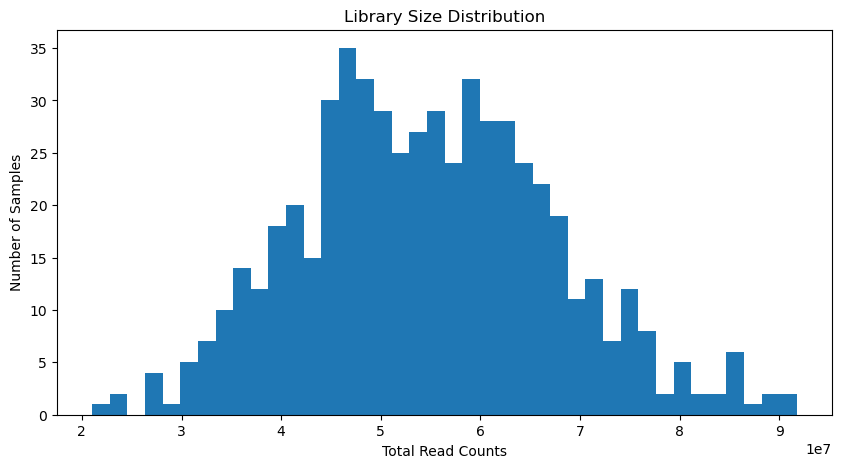

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.hist(library_sizes, bins=40)

plt.xlabel("Total Read Counts")
plt.ylabel("Number of Samples")
plt.title("Library Size Distribution")

plt.show()

In [22]:
expressed = (expression[patients] > 0).sum()

expressed.describe()

count      566.000000
mean     31270.261484
std       2778.010971
min      21768.000000
25%      29524.250000
50%      30919.000000
75%      32554.750000
max      45816.000000
dtype: float64

In [23]:
zero_genes = (expression[patients].sum(axis=1) == 0).sum()

print(f"Genes with zero counts across all samples: {zero_genes}")

Genes with zero counts across all samples: 2912


In [24]:
mean_counts = expression[patients].mean(axis=1)

top = expression[["gene_name"]].copy()
top["mean_count"] = mean_counts

top.sort_values("mean_count", ascending=False).head(20)

,gene_name,mean_count
16147,KRT5,800187.874558
16335,KRT14,720874.519435
20179,KRT6A,658396.802120
6022,KRT17,437155.507067
17874,MT-CO1,383666.409894
16331,KRT16,362115.768551
1316,ACTB,340602.902827
17923,MT-ND4,283747.832155
3591,COL1A1,278898.079505
21426,MT-RNR2,268516.480565


In [26]:
# Separate gene information from expression values
gene_info = expression[["gene_id", "gene_name"]].copy()

counts = expression.drop(columns=["gene_id", "gene_name"]).copy()

print("Gene info:", gene_info.shape)
print("Counts:", counts.shape)

Gene info: (60660, 2)
Counts: (60660, 566)


In [27]:
print("Before:", counts.shape)

keep = counts.sum(axis=1) > 0

counts = counts.loc[keep].reset_index(drop=True)
gene_info = gene_info.loc[keep].reset_index(drop=True)

print("After:", counts.shape)

Before: (60660, 566)
After: (57748, 566)


In [28]:
# Separate annotation and count matrix
gene_info = expression[["gene_id", "gene_name"]].copy()

counts = expression.drop(columns=["gene_id", "gene_name"]).copy()

print("Gene annotation:", gene_info.shape)
print("Count matrix:", counts.shape)

Gene annotation: (60660, 2)
Count matrix: (60660, 566)


In [29]:
print("="*60)
print("Removing genes with zero counts")
print("="*60)

before = counts.shape[0]

keep = counts.sum(axis=1) > 0

counts = counts.loc[keep].reset_index(drop=True)
gene_info = gene_info.loc[keep].reset_index(drop=True)

after = counts.shape[0]

print(f"Before : {before}")
print(f"After  : {after}")
print(f"Removed: {before-after}")

Removing genes with zero counts
Before : 60660
After  : 57748
Removed: 2912


In [30]:
print("="*60)
print("Filtering lowly expressed genes")
print("="*60)

before = counts.shape[0]

keep = (counts >= 10).sum(axis=1) >= 10

counts = counts.loc[keep].reset_index(drop=True)
gene_info = gene_info.loc[keep].reset_index(drop=True)

after = counts.shape[0]

print(f"Before : {before}")
print(f"After  : {after}")
print(f"Removed: {before-after}")

Filtering lowly expressed genes
Before : 57748
After  : 29791
Removed: 27957


In [31]:
print("="*60)
print("Normalizing to Counts Per Million (CPM)")
print("="*60)

library_size = counts.sum(axis=0)

cpm = counts.divide(library_size, axis=1) * 1e6

print(cpm.shape)

Normalizing to Counts Per Million (CPM)
(29791, 566)


In [34]:
log_cpm = np.log2(cpm + 1)

print(log_cpm.shape)

(29791, 566)


In [35]:
normalized = pd.concat(
    [gene_info.reset_index(drop=True),
     log_cpm.reset_index(drop=True)],
    axis=1
)

normalized.head()

,gene_id,gene_name,00493cfb-cfcf-4994-b4f4-3f1ff94e21f8,01392dce-a8df-4803-aa61-d14956d801a4,0163117a-2f64-4f00-b22e-d82254aaae0a,01938448-39ff-474a-865e-b41c5207f3bb,01d607fe-fc0b-441f-9528-8495666cd83e,0295ea9f-3c48-400e-8004-05ca911f460d,0302ccdb-2853-4679-be48-de365da40545,0398eb84-be87-4906-9e22-cb94494b54f6,...,f759de52-a9ad-494a-b618-74b6da07a769,f78434bc-dc0a-412b-871d-59b823b686dc,f8b3eb55-0a76-4f8c-bf8c-f99767c352fd,f8eaf87f-8ab3-4d10-954e-eb4e4a4e0b82,f97ae484-c4fd-4253-896e-3e3f96471f05,fbe956a0-66f9-4781-8f71-0a579f0d6921,fcc92fb1-5ea5-4a09-b529-af4c06e78dc9,fd434c3e-120b-4e22-bd02-25e97f36fb1e,fdb27f75-f853-44f8-a5c4-1ecf6ff27412,fe7ba23d-4829-4d00-a20f-2390c2bb22f6
0,ENSG00000000003.15,TSPAN6,3.539987,4.474651,5.859951,4.896626,5.490356,5.197152,4.324201,5.289340,...,5.587655,4.655861,4.686478,5.617217,6.655702,7.539215,5.717064,5.996842,7.403222,5.598237
1,ENSG00000000005.6,TNMD,0.030536,0.022614,0.000000,0.021912,0.439813,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.055376,0.000000,0.053288,0.105009,0.000000,0.000000,0.190814,0.000000
2,ENSG00000000419.13,DPM1,5.833519,4.992717,5.508154,4.956873,5.042088,5.396805,5.205444,5.075256,...,5.392355,5.580626,5.166064,5.301656,5.417122,4.752598,4.523338,5.387708,4.680999,5.181130
3,ENSG00000000457.14,SCYL3,3.037207,3.211427,3.030118,3.513769,3.019670,3.745030,2.758370,3.329098,...,3.387299,4.013470,3.519444,3.357389,3.504294,3.707639,3.763992,3.292432,4.149658,3.415086
4,ENSG00000000460.17,C1orf112,2.805226,3.176560,2.653244,4.211275,1.959381,2.741548,2.554083,3.098191,...,4.946135,4.357622,3.125673,2.933715,3.248490,2.562561,4.432996,3.478191,2.432782,4.114618


In [36]:
from pathlib import Path

output_dir = Path("../merged")
output_dir.mkdir(exist_ok=True)

normalized.to_csv(
    output_dir / "normalized_logCPM.csv",
    index=False
)

print("Normalized matrix saved.")

Normalized matrix saved.


In [37]:
print("="*60)
print("Log2 Transformation")
print("="*60)

log_cpm = np.log2(cpm + 1)

print(log_cpm.shape)

Log2 Transformation
(29791, 566)


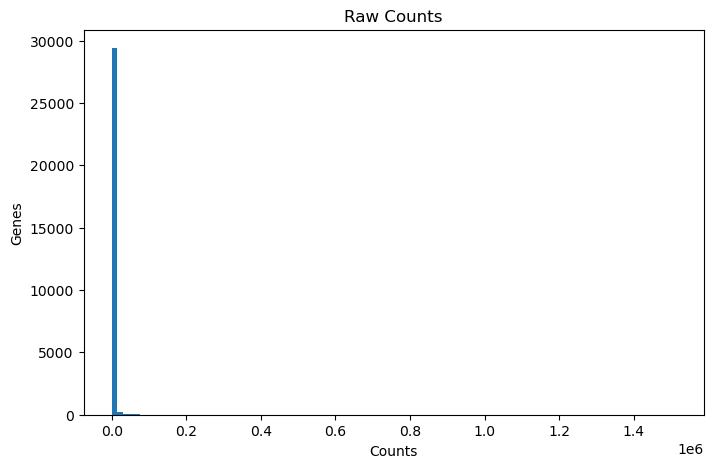

In [38]:
plt.figure(figsize=(8,5))

plt.hist(counts.iloc[:,0], bins=100)

plt.title("Raw Counts")
plt.xlabel("Counts")
plt.ylabel("Genes")

plt.show()

In [39]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [40]:
X = log_cpm.T

X_scaled = StandardScaler().fit_transform(X)

pca = PCA(n_components=2)

pcs = pca.fit_transform(X_scaled)

print(f"PC1: {100*pca.explained_variance_ratio_[0]:.2f}%")
print(f"PC2: {100*pca.explained_variance_ratio_[1]:.2f}%")

PC1: 11.38%
PC2: 7.69%


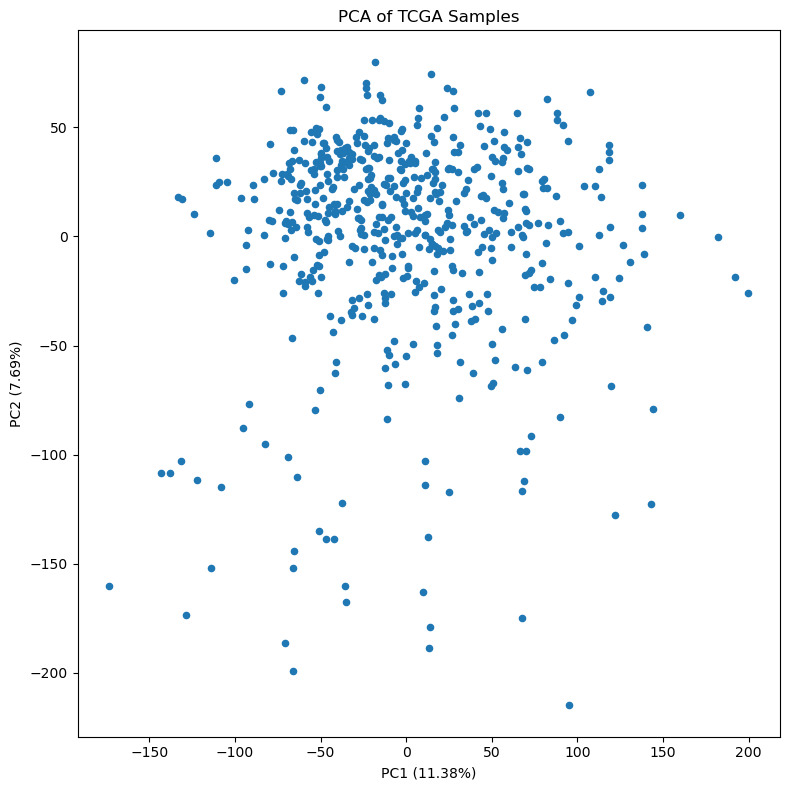

In [41]:
plt.figure(figsize=(8,8))

plt.scatter(pcs[:,0], pcs[:,1], s=20)

plt.xlabel(f"PC1 ({100*pca.explained_variance_ratio_[0]:.2f}%)")
plt.ylabel(f"PC2 ({100*pca.explained_variance_ratio_[1]:.2f}%)")

plt.title("PCA of TCGA Samples")

plt.tight_layout()
plt.show()

In [43]:
from pathlib import Path

print("Current working directory:")
print(Path.cwd())

print("\nFiles in this directory:")
for f in sorted(Path.cwd().iterdir()):
    print(f.name)

Current working directory:
/Users/sampoorn/TCGA_project/data/raw

Files in this directory:
.DS_Store
00493cfb-cfcf-4994-b4f4-3f1ff94e21f8
01392dce-a8df-4803-aa61-d14956d801a4
0163117a-2f64-4f00-b22e-d82254aaae0a
01938448-39ff-474a-865e-b41c5207f3bb
01_build_expression_matrix.ipynb
01_merge_counts.ipynb
01d607fe-fc0b-441f-9528-8495666cd83e
0295ea9f-3c48-400e-8004-05ca911f460d
0302ccdb-2853-4679-be48-de365da40545
0398eb84-be87-4906-9e22-cb94494b54f6
03a11c55-c144-4215-a996-391eed03cc80
0401cfb1-2922-40fb-bb2c-f5c6966dbe49
041aeb93-f142-40c9-a878-2a10d3d1d2cf
044de6e3-52f7-493c-b8d2-6aeca52375ea
045ffab4-4408-4550-b46c-ba0b237bb00f
0486cbe7-ea63-4a75-8bad-7e95993b34ce
049fed5d-ea56-4406-8db9-0118d23c490b
0508b025-15b5-4012-b1b1-530d329eeec9
05ca7f3b-7b27-46f7-960b-5ce2deae5c13
060bb9a8-70e4-48bf-949a-9a4da4fe321f
0621ca2f-3e91-4b15-8989-1bd6ec48131f
0671f907-5a87-4d69-b18b-353e123b04a0
06c46190-b2e2-4c28-9dd8-ec9df9b3faac
07f3248f-4c22-441e-8b7e-18a77064d984
088f29fa-5f7b-4ae6-8a57-92bffe

In [45]:
from pathlib import Path

print(Path("clinical.tsv").exists())
print(Path("gdc_sample_sheet.2026-06-24.tsv").exists())
print(Path("normalized_logCPM.csv").exists())

True
True
False


In [46]:
clinical = pd.read_csv("clinical.tsv", sep="\t", low_memory=False)

sample_sheet = pd.read_csv("gdc_sample_sheet.2026-06-24.tsv", sep="\t")

# expression is already in memory
print(clinical.shape)
print(sample_sheet.shape)
print(expression.shape)

(2179, 201)
(566, 11)
(60660, 568)


In [47]:
print(sample_sheet.columns.tolist())

['File ID', 'File Name', 'Data Category', 'Data Type', 'Project ID', 'Case ID', 'Sample ID', 'Tissue Type', 'Tumor Descriptor', 'Specimen Type', 'Preservation Method']


In [48]:
print(clinical.columns.tolist())

['project.project_id', 'cases.case_id', 'cases.consent_type', 'cases.days_to_consent', 'cases.days_to_lost_to_followup', 'cases.disease_type', 'cases.index_date', 'cases.lost_to_followup', 'cases.primary_site', 'cases.submitter_id', 'demographic.age_at_index', 'demographic.age_is_obfuscated', 'demographic.cause_of_death', 'demographic.cause_of_death_source', 'demographic.country_of_birth', 'demographic.country_of_residence_at_enrollment', 'demographic.days_to_birth', 'demographic.days_to_death', 'demographic.demographic_id', 'demographic.education_level', 'demographic.ethnicity', 'demographic.gender', 'demographic.marital_status', 'demographic.occupation_duration_years', 'demographic.population_group', 'demographic.race', 'demographic.sex_at_birth', 'demographic.submitter_id', 'demographic.vital_status', 'demographic.year_of_birth', 'demographic.year_of_death', 'diagnoses.adrenal_hormone', 'diagnoses.age_at_diagnosis', 'diagnoses.ajcc_clinical_m', 'diagnoses.ajcc_clinical_n', 'diagnose

In [49]:
clinical_small = clinical[
    [
        "cases.case_id",
        "cases.submitter_id",
        "demographic.vital_status",
        "demographic.days_to_death",
        "diagnoses.days_to_last_follow_up",
        "diagnoses.age_at_diagnosis",
        "diagnoses.ajcc_pathologic_stage",
        "demographic.gender"
    ]
].copy()

print(clinical_small.shape)
clinical_small.head()

(2179, 8)


,cases.case_id,cases.submitter_id,demographic.vital_status,demographic.days_to_death,diagnoses.days_to_last_follow_up,diagnoses.age_at_diagnosis,diagnoses.ajcc_pathologic_stage,demographic.gender
0,01420c4e-6013-4d3f-87bd-a6cd9e3f8e87,TCGA-BA-5152,Alive,'--,1288.0,20783,Stage IVA,male
1,01420c4e-6013-4d3f-87bd-a6cd9e3f8e87,TCGA-BA-5152,Alive,'--,1288.0,20783,Stage IVA,male
2,02dcc11f-4f0e-4c9e-8d96-d22d47beef5d,TCGA-CQ-5329,Alive,'--,2143.0,17028,Stage II,female
3,02dcc11f-4f0e-4c9e-8d96-d22d47beef5d,TCGA-CQ-5329,Alive,'--,2143.0,17028,Stage II,female
4,02dcc11f-4f0e-4c9e-8d96-d22d47beef5d,TCGA-CQ-5329,Alive,'--,2143.0,17028,Stage II,female


In [50]:
clinical_small = clinical_small.drop_duplicates(
    subset="cases.case_id"
)

print(clinical_small.shape)

(521, 8)


In [51]:
sample_clinical = sample_sheet.merge(
    clinical_small,
    left_on="Case ID",
    right_on="cases.case_id",
    how="left"
)

print(sample_clinical.shape)
sample_clinical.head()

(566, 19)


,File ID,File Name,Data Category,Data Type,Project ID,Case ID,Sample ID,Tissue Type,Tumor Descriptor,Specimen Type,Preservation Method,cases.case_id,cases.submitter_id,demographic.vital_status,demographic.days_to_death,diagnoses.days_to_last_follow_up,diagnoses.age_at_diagnosis,diagnoses.ajcc_pathologic_stage,demographic.gender
0,28a3b4b9-ee0e-4554-8c5d-9fe619e81564,eb0e6381-873f-43cc-a78a-22fb5dd7c9b0.rna_seq.a...,Transcriptome Profiling,Gene Expression Quantification,TCGA-HNSC,TCGA-CQ-6221,TCGA-CQ-6221-01A,Tumor,Primary,Solid Tissue,Unknown,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,9adb359c-7196-4b9e-8cd7-b6b207521db4,efdfb4b0-ba6f-43e1-ba1a-6f22e396a1a5.rna_seq.a...,Transcriptome Profiling,Gene Expression Quantification,TCGA-HNSC,TCGA-IQ-7631,TCGA-IQ-7631-01A,Tumor,Primary,Solid Tissue,Unknown,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,6bbf7ecc-6210-4173-956a-aa241cbbff2c,c83c1267-97c6-410a-9922-af05e099e427.rna_seq.a...,Transcriptome Profiling,Gene Expression Quantification,TCGA-HNSC,TCGA-CV-7406,TCGA-CV-7406-01A,Tumor,Primary,Solid Tissue,Unknown,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,5ed98c17-8df8-48b3-a6f9-3d5c33119e26,9153c561-deb3-4465-b6c3-b20199689228.rna_seq.a...,Transcriptome Profiling,Gene Expression Quantification,TCGA-HNSC,TCGA-DQ-7589,TCGA-DQ-7589-01A,Tumor,Primary,Solid Tissue,Unknown,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4a4b8437-d003-4149-9770-fa8365eb3430,29e20159-988e-4e50-985b-b3628a9e45f4.rna_seq.a...,Transcriptome Profiling,Gene Expression Quantification,TCGA-HNSC,TCGA-CN-6021,TCGA-CN-6021-01A,Tumor,Primary,Solid Tissue,Unknown,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [52]:
sample_clinical["OS_days"] = sample_clinical[
    "demographic.days_to_death"
].fillna(
    sample_clinical["diagnoses.days_to_last_follow_up"]
)

/var/folders/7p/x3y7xk251jvf0cl1kmd__y6m0000gn/T/ipykernel_62298/3293705036.py:3: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  ].fillna(


In [53]:
sample_clinical["Event"] = (
    sample_clinical["demographic.vital_status"] == "Dead"
).astype(int)

In [54]:
print(sample_clinical[["OS_days","Event"]].describe())

print()

print(sample_clinical["Event"].value_counts(dropna=False))

       OS_days  Event
count      0.0  566.0
mean       NaN    0.0
std        NaN    0.0
min        NaN    0.0
25%        NaN    0.0
50%        NaN    0.0
75%        NaN    0.0
max        NaN    0.0

Event
0    566
Name: count, dtype: int64


In [55]:
print(sample_sheet["Case ID"].head())
print()
print(clinical_small["cases.case_id"].head())


0    TCGA-CQ-6221
1    TCGA-IQ-7631
2    TCGA-CV-7406
3    TCGA-DQ-7589
4    TCGA-CN-6021
Name: Case ID, dtype: object

0     01420c4e-6013-4d3f-87bd-a6cd9e3f8e87
2     02dcc11f-4f0e-4c9e-8d96-d22d47beef5d
5     0394060d-010e-405f-983d-db525f01f2c3
15    039788ec-1364-40c7-9e9d-13dc305674e9
20    03aca47b-7653-4938-9178-ed7c37eee6d5
Name: cases.case_id, dtype: object


In [56]:
print(sample_clinical["cases.case_id"].notna().sum())

0


In [57]:
sample_clinical = sample_sheet.merge(
    clinical_small,
    left_on="Case ID",
    right_on="cases.submitter_id",
    how="left"
)

print(sample_clinical.shape)
print(sample_clinical["cases.submitter_id"].notna().sum())

(566, 19)
566


In [58]:
sample_clinical["OS_days"] = sample_clinical[
    "demographic.days_to_death"
].fillna(
    sample_clinical["diagnoses.days_to_last_follow_up"]
)

sample_clinical["Event"] = (
    sample_clinical["demographic.vital_status"] == "Dead"
).astype(int)

In [59]:
print(sample_clinical["Event"].value_counts(dropna=False))

print(sample_clinical["OS_days"].describe())

Event
0    311
1    255
Name: count, dtype: int64
count     566
unique    204
top       '--
freq      313
Name: OS_days, dtype: object


In [60]:
import numpy as np

# Replace '--' with missing values
sample_clinical["demographic.days_to_death"] = (
    sample_clinical["demographic.days_to_death"]
    .replace("'--", np.nan)
    .replace("--", np.nan)
)

sample_clinical["diagnoses.days_to_last_follow_up"] = (
    sample_clinical["diagnoses.days_to_last_follow_up"]
    .replace("'--", np.nan)
    .replace("--", np.nan)
)

# Convert to numeric
sample_clinical["demographic.days_to_death"] = pd.to_numeric(
    sample_clinical["demographic.days_to_death"],
    errors="coerce"
)

sample_clinical["diagnoses.days_to_last_follow_up"] = pd.to_numeric(
    sample_clinical["diagnoses.days_to_last_follow_up"],
    errors="coerce"
)

# Overall survival time
sample_clinical["OS_days"] = sample_clinical[
    "demographic.days_to_death"
].fillna(
    sample_clinical["diagnoses.days_to_last_follow_up"]
)

print(sample_clinical["OS_days"].describe())

count     520.000000
mean      917.505769
std       897.538181
min         1.000000
25%       360.000000
50%       633.000000
75%      1173.750000
max      6417.000000
Name: OS_days, dtype: float64


In [61]:
sample_clinical.to_csv(
    "clinical_expression_metadata.csv",
    index=False
)

print("Saved!")

Saved!


In [62]:
analysis = sample_clinical.dropna(subset=["OS_days"]).copy()

print("Patients for survival:", analysis.shape[0])

analysis["Event"] = analysis["Event"].astype(int)

analysis[["Case ID","OS_days","Event"]].head()

Patients for survival: 520


,Case ID,OS_days,Event
1,TCGA-IQ-7631,1172.0,0
2,TCGA-CV-7406,1748.0,1
4,TCGA-CN-6021,276.0,1
6,TCGA-F7-A620,543.0,0
7,TCGA-CV-5431,522.0,1


In [63]:
print(expression.shape)

print(expression.columns[:10])

print(expression.iloc[:5, :5])

(60660, 568)
Index(['gene_id', 'gene_name', '00493cfb-cfcf-4994-b4f4-3f1ff94e21f8',
       '01392dce-a8df-4803-aa61-d14956d801a4',
       '0163117a-2f64-4f00-b22e-d82254aaae0a',
       '01938448-39ff-474a-865e-b41c5207f3bb',
       '01d607fe-fc0b-441f-9528-8495666cd83e',
       '0295ea9f-3c48-400e-8004-05ca911f460d',
       '0302ccdb-2853-4679-be48-de365da40545',
       '0398eb84-be87-4906-9e22-cb94494b54f6'],
      dtype='object')
              gene_id gene_name  00493cfb-cfcf-4994-b4f4-3f1ff94e21f8  \
0  ENSG00000000003.15    TSPAN6                                   497   
1   ENSG00000000005.6      TNMD                                     1   
2  ENSG00000000419.13      DPM1                                  2619   
3  ENSG00000000457.14     SCYL3                                   337   
4  ENSG00000000460.17  C1orf112                                   280   

   01392dce-a8df-4803-aa61-d14956d801a4  0163117a-2f64-4f00-b22e-d82254aaae0a  
0                                  1344      

In [65]:
import json
import pandas as pd

with open("metadata.cart.2026-06-24.json") as f:
    meta = json.load(f)

print(type(meta))
print("Entries:", len(meta))
print(meta[0].keys())

<class 'list'>
Entries: 566
dict_keys(['data_format', 'access', 'associated_entities', 'file_name', 'submitter_id', 'data_category', 'annotations', 'analysis', 'platform', 'file_size', 'md5sum', 'file_id', 'data_type', 'state', 'experimental_strategy'])


In [66]:
import pandas as pd

rows = []

for x in meta:
    rows.append({
        "File ID": x.get("file_id"),
        "File Name": x.get("file_name"),
        "Case ID": x["associated_entities"][0]["case_id"]
        if x.get("associated_entities") else None
    })

metadata = pd.DataFrame(rows)

metadata.head()

,File ID,File Name,Case ID
0,28a3b4b9-ee0e-4554-8c5d-9fe619e81564,eb0e6381-873f-43cc-a78a-22fb5dd7c9b0.rna_seq.a...,839b660c-98fe-4468-a2b3-408594350250
1,9adb359c-7196-4b9e-8cd7-b6b207521db4,efdfb4b0-ba6f-43e1-ba1a-6f22e396a1a5.rna_seq.a...,d8a6383e-3320-4d2c-9017-31e8e1e8f120
2,6bbf7ecc-6210-4173-956a-aa241cbbff2c,c83c1267-97c6-410a-9922-af05e099e427.rna_seq.a...,2c6d6c93-fb6d-47f7-a868-5e9a82c75d4c
3,5ed98c17-8df8-48b3-a6f9-3d5c33119e26,9153c561-deb3-4465-b6c3-b20199689228.rna_seq.a...,4648225e-5b68-488a-969a-e8d812190c6f
4,4a4b8437-d003-4149-9770-fa8365eb3430,29e20159-988e-4e50-985b-b3628a9e45f4.rna_seq.a...,9eb1997f-14f5-4230-ae4f-1ef1943e1723


In [67]:
print(metadata.shape)
print(metadata.head())

(566, 3)
                                File ID  \
0  28a3b4b9-ee0e-4554-8c5d-9fe619e81564   
1  9adb359c-7196-4b9e-8cd7-b6b207521db4   
2  6bbf7ecc-6210-4173-956a-aa241cbbff2c   
3  5ed98c17-8df8-48b3-a6f9-3d5c33119e26   
4  4a4b8437-d003-4149-9770-fa8365eb3430   

                                           File Name  \
0  eb0e6381-873f-43cc-a78a-22fb5dd7c9b0.rna_seq.a...   
1  efdfb4b0-ba6f-43e1-ba1a-6f22e396a1a5.rna_seq.a...   
2  c83c1267-97c6-410a-9922-af05e099e427.rna_seq.a...   
3  9153c561-deb3-4465-b6c3-b20199689228.rna_seq.a...   
4  29e20159-988e-4e50-985b-b3628a9e45f4.rna_seq.a...   

                                Case ID  
0  839b660c-98fe-4468-a2b3-408594350250  
1  d8a6383e-3320-4d2c-9017-31e8e1e8f120  
2  2c6d6c93-fb6d-47f7-a868-5e9a82c75d4c  
3  4648225e-5b68-488a-969a-e8d812190c6f  
4  9eb1997f-14f5-4230-ae4f-1ef1943e1723  


In [68]:
import json
from pprint import pprint

pprint(meta[0])

{'access': 'open',
 'analysis': {'analysis_id': '4fac4690-4dc0-4e44-a2c6-86ef003c2a2b',
              'created_datetime': '2021-12-13T18:35:35.681742-06:00',
              'input_files': [{'access': 'controlled',
                               'average_base_quality': 37,
                               'average_insert_size': 1271,
                               'average_read_length': 48,
                               'created_datetime': '2021-12-13T17:25:14.825923-06:00',
                               'data_category': 'Sequencing Reads',
                               'data_format': 'BAM',
                               'data_type': 'Aligned Reads',
                               'experimental_strategy': 'RNA-Seq',
                               'file_id': 'f5cb0e55-45ac-492f-b8f3-b88ed52fb673',
                               'file_name': 'eb0e6381-873f-43cc-a78a-22fb5dd7c9b0.rna_seq.genomic.gdc_realn.bam',
                               'file_size': 7142838637,
                      

In [69]:
print(meta[0]["associated_entities"])

[{'entity_submitter_id': 'TCGA-CQ-6221-01A-11R-2081-07', 'entity_type': 'aliquot', 'case_id': '839b660c-98fe-4468-a2b3-408594350250', 'entity_id': '87af91c1-5a24-4353-af16-5ea2d5efc089'}]


In [70]:
rows = []

for x in meta:
    rows.append({
        "File ID": x["file_name"].split(".")[0],   # folder/file UUID used in expression matrix
        "Patient": x["associated_entities"][0]["entity_submitter_id"][:12]
    })

metadata = pd.DataFrame(rows)

metadata.head()

,File ID,Patient
0,eb0e6381-873f-43cc-a78a-22fb5dd7c9b0,TCGA-CQ-6221
1,efdfb4b0-ba6f-43e1-ba1a-6f22e396a1a5,TCGA-IQ-7631
2,c83c1267-97c6-410a-9922-af05e099e427,TCGA-CV-7406
3,9153c561-deb3-4465-b6c3-b20199689228,TCGA-DQ-7589
4,29e20159-988e-4e50-985b-b3628a9e45f4,TCGA-CN-6021


In [71]:
print(metadata.shape)
metadata.head()

(566, 2)


,File ID,Patient
0,eb0e6381-873f-43cc-a78a-22fb5dd7c9b0,TCGA-CQ-6221
1,efdfb4b0-ba6f-43e1-ba1a-6f22e396a1a5,TCGA-IQ-7631
2,c83c1267-97c6-410a-9922-af05e099e427,TCGA-CV-7406
3,9153c561-deb3-4465-b6c3-b20199689228,TCGA-DQ-7589
4,29e20159-988e-4e50-985b-b3628a9e45f4,TCGA-CN-6021


In [72]:
file_to_patient = dict(zip(metadata["File ID"], metadata["Patient"]))

expression2 = expression.copy()

expression2.columns = [
    file_to_patient.get(c, c)
    if c not in ["gene_id", "gene_name"]
    else c
    for c in expression2.columns
]

expression2.iloc[:5, :8]

,gene_id,gene_name,00493cfb-cfcf-4994-b4f4-3f1ff94e21f8,01392dce-a8df-4803-aa61-d14956d801a4,0163117a-2f64-4f00-b22e-d82254aaae0a,01938448-39ff-474a-865e-b41c5207f3bb,01d607fe-fc0b-441f-9528-8495666cd83e,0295ea9f-3c48-400e-8004-05ca911f460d
0,ENSG00000000003.15,TSPAN6,497,1344,3161,1881,2343,1763
1,ENSG00000000005.6,TNMD,1,1,0,1,19,0
2,ENSG00000000419.13,DPM1,2619,1952,2465,1964,1703,2032
3,ENSG00000000457.14,SCYL3,337,523,397,681,379,613
4,ENSG00000000460.17,C1orf112,280,509,293,1145,154,281


In [73]:
expr_patients = set(expression2.columns[2:])
clinical_patients = set(sample_clinical["Case ID"])

print("Expression patients :", len(expr_patients))
print("Clinical patients   :", len(clinical_patients))
print("Common patients     :", len(expr_patients & clinical_patients))

Expression patients : 566
Clinical patients   : 521
Common patients     : 0


In [74]:
print(sample_clinical["Case ID"].head(10))

print()

print(expression2.columns[2:12])

print()

print(sample_clinical["Case ID"].str.len().value_counts())

print()

print([repr(x) for x in expression2.columns[2:7]])

0    TCGA-CQ-6221
1    TCGA-IQ-7631
2    TCGA-CV-7406
3    TCGA-DQ-7589
4    TCGA-CN-6021
5    TCGA-CN-4741
6    TCGA-F7-A620
7    TCGA-CV-5431
8    TCGA-CV-7424
9    TCGA-CN-4737
Name: Case ID, dtype: object

Index(['00493cfb-cfcf-4994-b4f4-3f1ff94e21f8',
       '01392dce-a8df-4803-aa61-d14956d801a4',
       '0163117a-2f64-4f00-b22e-d82254aaae0a',
       '01938448-39ff-474a-865e-b41c5207f3bb',
       '01d607fe-fc0b-441f-9528-8495666cd83e',
       '0295ea9f-3c48-400e-8004-05ca911f460d',
       '0302ccdb-2853-4679-be48-de365da40545',
       '0398eb84-be87-4906-9e22-cb94494b54f6',
       '03a11c55-c144-4215-a996-391eed03cc80',
       '0401cfb1-2922-40fb-bb2c-f5c6966dbe49'],
      dtype='object')

Case ID
12    566
Name: count, dtype: int64

["'00493cfb-cfcf-4994-b4f4-3f1ff94e21f8'", "'01392dce-a8df-4803-aa61-d14956d801a4'", "'0163117a-2f64-4f00-b22e-d82254aaae0a'", "'01938448-39ff-474a-865e-b41c5207f3bb'", "'01d607fe-fc0b-441f-9528-8495666cd83e'"]


In [75]:
manifest = pd.read_csv("gdc_manifest.2026-06-24.014844.txt", sep="\t")

print(manifest.columns)

print(manifest.head())

Index(['id', 'filename', 'md5', 'size', 'state'], dtype='object')
                                     id  \
0  28a3b4b9-ee0e-4554-8c5d-9fe619e81564   
1  9adb359c-7196-4b9e-8cd7-b6b207521db4   
2  6bbf7ecc-6210-4173-956a-aa241cbbff2c   
3  5ed98c17-8df8-48b3-a6f9-3d5c33119e26   
4  4a4b8437-d003-4149-9770-fa8365eb3430   

                                            filename  \
0  eb0e6381-873f-43cc-a78a-22fb5dd7c9b0.rna_seq.a...   
1  efdfb4b0-ba6f-43e1-ba1a-6f22e396a1a5.rna_seq.a...   
2  c83c1267-97c6-410a-9922-af05e099e427.rna_seq.a...   
3  9153c561-deb3-4465-b6c3-b20199689228.rna_seq.a...   
4  29e20159-988e-4e50-985b-b3628a9e45f4.rna_seq.a...   

                                md5     size     state  
0  1523605578fc78eface41725b4c4f496  4226868  released  
1  9ab83dd5f742478a2b254f0098619691  4225312  released  
2  d1d9dd7756c57681f528e2b3a2446853  4245009  released  
3  4d9cbe02291e747042da05ec0ba46441  4248542  released  
4  412d392cce39adbd0ccc542eeafced79  4226742  release

In [76]:
from pathlib import Path

folder = Path("00493cfb-cfcf-4994-b4f4-3f1ff94e21f8")

print("Contents:")
for f in folder.iterdir():
    print(f.name)

Contents:
logs
6d1ffd0c-ba13-463e-b5c4-20d2dab6294d.rna_seq.augmented_star_gene_counts.tsv


In [77]:
from pathlib import Path

log_dir = Path("00493cfb-cfcf-4994-b4f4-3f1ff94e21f8/logs")

print("Files inside logs:")
for f in log_dir.iterdir():
    print(f.name)
    

Files inside logs:
6d1ffd0c-ba13-463e-b5c4-20d2dab6294d.rna_seq.augmented_star_gene_counts.tsv.parcel


In [78]:
from pathlib import Path

mapping = {}

for folder in Path(".").iterdir():
    if folder.is_dir():
        tsvs = list(folder.glob("*.rna_seq.augmented_star_gene_counts.tsv"))
        if len(tsvs) == 1:
            mapping[folder.name] = tsvs[0].stem.replace(".rna_seq.augmented_star_gene_counts","")

print("Mappings:", len(mapping))

list(mapping.items())[:5]

Mappings: 566


[('40d8ec31-60e2-4c0b-ae9b-c5910e2cebba',
  '67d3e1d0-3643-4964-a966-632eade7711b'),
 ('c3afcb4c-394b-4876-aa92-00500e9bf740',
  '335bea46-446e-4187-9078-751fb229913d'),
 ('cf40df1f-3037-405b-b652-ff6a6f9d9085',
  '2d42310d-fc2c-4c72-9873-757640c9ccea'),
 ('7ed2198a-102d-42e2-8cf0-d8dfbdf34632',
  'fa60d195-2f77-40ef-a304-19fe7e14f368'),
 ('55ffd417-0e61-4fe5-9ba4-54ae15c8330a',
  '18075aee-7064-4b22-b976-21f93af49218')]

In [79]:
expression = expression.rename(columns=mapping)

print(expression.columns[:10])

Index(['gene_id', 'gene_name', '6d1ffd0c-ba13-463e-b5c4-20d2dab6294d',
       '1296f6cf-ced5-42ce-9aac-0d30eb630f1a',
       '2761f674-9dbe-435c-b91c-70f854eeebfd',
       '8c9688b2-7aaf-4041-94cb-1882149a2eaf',
       '8ccd8cbb-c886-4fc4-b3d2-19476681da78',
       '31a7d787-3d81-4ee0-8995-1579c57bc29d',
       '6d0be676-7196-464a-b521-8f0ecd6322f2',
       '85de0d7a-0624-4cd6-a33f-146b11b1b306'],
      dtype='object')


In [80]:
print(expression.columns[:10])

Index(['gene_id', 'gene_name', '6d1ffd0c-ba13-463e-b5c4-20d2dab6294d',
       '1296f6cf-ced5-42ce-9aac-0d30eb630f1a',
       '2761f674-9dbe-435c-b91c-70f854eeebfd',
       '8c9688b2-7aaf-4041-94cb-1882149a2eaf',
       '8ccd8cbb-c886-4fc4-b3d2-19476681da78',
       '31a7d787-3d81-4ee0-8995-1579c57bc29d',
       '6d0be676-7196-464a-b521-8f0ecd6322f2',
       '85de0d7a-0624-4cd6-a33f-146b11b1b306'],
      dtype='object')


In [81]:
import json
import pandas as pd

with open("metadata.cart.2026-06-24.json") as f:
    meta = json.load(f)

rows = []

for x in meta:
    rows.append({
        "RNA_UUID": x["file_name"].replace(".rna_seq.augmented_star_gene_counts.tsv", ""),
        "Case_ID": x["associated_entities"][0]["case_id"]
    })

uuid_map = pd.DataFrame(rows)

print(uuid_map.shape)
uuid_map.head()

(566, 2)


,RNA_UUID,Case_ID
0,eb0e6381-873f-43cc-a78a-22fb5dd7c9b0,839b660c-98fe-4468-a2b3-408594350250
1,efdfb4b0-ba6f-43e1-ba1a-6f22e396a1a5,d8a6383e-3320-4d2c-9017-31e8e1e8f120
2,c83c1267-97c6-410a-9922-af05e099e427,2c6d6c93-fb6d-47f7-a868-5e9a82c75d4c
3,9153c561-deb3-4465-b6c3-b20199689228,4648225e-5b68-488a-969a-e8d812190c6f
4,29e20159-988e-4e50-985b-b3628a9e45f4,9eb1997f-14f5-4230-ae4f-1ef1943e1723


In [82]:
case_to_patient = dict(
    zip(
        clinical["cases.case_id"],
        clinical["cases.submitter_id"]
    )
)

uuid_map["Patient_ID"] = uuid_map["Case_ID"].map(case_to_patient)

print(uuid_map.head())
print()
print("Mapped patients:", uuid_map["Patient_ID"].notna().sum())

                               RNA_UUID                               Case_ID  \
0  eb0e6381-873f-43cc-a78a-22fb5dd7c9b0  839b660c-98fe-4468-a2b3-408594350250   
1  efdfb4b0-ba6f-43e1-ba1a-6f22e396a1a5  d8a6383e-3320-4d2c-9017-31e8e1e8f120   
2  c83c1267-97c6-410a-9922-af05e099e427  2c6d6c93-fb6d-47f7-a868-5e9a82c75d4c   
3  9153c561-deb3-4465-b6c3-b20199689228  4648225e-5b68-488a-969a-e8d812190c6f   
4  29e20159-988e-4e50-985b-b3628a9e45f4  9eb1997f-14f5-4230-ae4f-1ef1943e1723   

     Patient_ID  
0  TCGA-CQ-6221  
1  TCGA-IQ-7631  
2  TCGA-CV-7406  
3  TCGA-DQ-7589  
4  TCGA-CN-6021  

Mapped patients: 566


In [83]:
rna_to_patient = dict(
    zip(uuid_map["RNA_UUID"], uuid_map["Patient_ID"])
)

expression = expression.rename(columns=rna_to_patient)

print(expression.columns[:10])

Index(['gene_id', 'gene_name', 'TCGA-CV-A463', 'TCGA-CV-7102', 'TCGA-BA-A6DL',
       'TCGA-CR-6471', 'TCGA-CV-6961', 'TCGA-CQ-A4CE', 'TCGA-CQ-5333',
       'TCGA-DQ-7592'],
      dtype='object')


In [84]:
# Expression patient IDs
expr_patients = set(expression.columns[2:])

# Clinical patient IDs
clinical_patients = set(clinical["cases.submitter_id"])

common = sorted(expr_patients.intersection(clinical_patients))

print("Expression patients :", len(expr_patients))
print("Clinical patients   :", len(clinical_patients))
print("Common patients     :", len(common))

Expression patients : 521
Clinical patients   : 521
Common patients     : 521


In [86]:
# Create the final expression matrix
expr = expression[
    ["gene_id", "gene_name"] + common
].copy()

print(expr.shape)

(60660, 568)


In [ ]:
# Recreate the survival dataframe

survival = clinical[
    ["cases.submitter_id", "OS_days", "Event"]
].copy()

survival = survival.rename(
    columns={"cases.submitter_id": "Patient_ID"}
)

survival = survival.dropna(subset=["OS_days"])

survival["OS_days"] = survival["OS_days"].astype(float)
survival["Event"] = survival["Event"].astype(aint)

print(survival.shape)
survival.head()

KeyError: "['OS_days', 'Event'] not in index"

In [ ]:
clinical.columns.tolist()

['project.project_id',
 'cases.case_id',
 'cases.consent_type',
 'cases.days_to_consent',
 'cases.days_to_lost_to_followup',
 'cases.disease_type',
 'cases.index_date',
 'cases.lost_to_followup',
 'cases.primary_site',
 'cases.submitter_id',
 'demographic.age_at_index',
 'demographic.age_is_obfuscated',
 'demographic.cause_of_death',
 'demographic.cause_of_death_source',
 'demographic.country_of_birth',
 'demographic.country_of_residence_at_enrollment',
 'demographic.days_to_birth',
 'demographic.days_to_death',
 'demographic.demographic_id',
 'demographic.education_level',
 'demographic.ethnicity',
 'demographic.gender',
 'demographic.marital_status',
 'demographic.occupation_duration_years',
 'demographic.population_group',
 'demographic.race',
 'demographic.sex_at_birth',
 'demographic.submitter_id',
 'demographic.vital_status',
 'demographic.year_of_birth',
 'demographic.year_of_death',
 'diagnoses.adrenal_hormone',
 'diagnoses.age_at_diagnosis',
 'diagnoses.ajcc_clinical_m',
 'dia

In [90]:
import numpy as np

# Event: 1 = dead, 0 = alive
clinical["Event"] = (
    clinical["demographic.vital_status"]
    .astype(str)
    .str.upper()
    .eq("DEAD")
    .astype(int)
)

# Overall survival time
clinical["OS_days"] = np.where(
    clinical["Event"] == 1,
    clinical["demographic.days_to_death"],
    clinical["diagnoses.days_to_last_follow_up"]
)

clinical["OS_days"] = pd.to_numeric(clinical["OS_days"], errors="coerce")

print(clinical[["cases.submitter_id","OS_days","Event"]].head())

print("\nPatients with survival data:",
      clinical["OS_days"].notna().sum())

  cases.submitter_id  OS_days  Event
0       TCGA-BA-5152   1288.0      0
1       TCGA-BA-5152   1288.0      0
2       TCGA-CQ-5329   2143.0      0
3       TCGA-CQ-5329   2143.0      0
4       TCGA-CQ-5329   2143.0      0

Patients with survival data: 1911


In [91]:
survival = clinical[
    ["cases.submitter_id", "OS_days", "Event"]
].copy()

survival.to_csv("HNSC_survival_521_patients.csv", index=False)

print(survival.shape)

(2179, 3)


In [92]:
import pandas as pd
import numpy as np

expr = pd.read_csv("HNSC_expression_521_patients.csv")

print(expr.shape)
expr.head()

(60660, 568)


,gene_id,gene_name,TCGA-4P-AA8J,TCGA-BA-4074,TCGA-BA-4075,TCGA-BA-4076,TCGA-BA-4077,TCGA-BA-4078,TCGA-BA-5149,TCGA-BA-5151,...,TCGA-UF-A7JJ,TCGA-UF-A7JK,TCGA-UF-A7JO,TCGA-UF-A7JS,TCGA-UF-A7JT,TCGA-UF-A7JV,TCGA-UP-A6WW,TCGA-WA-A7GZ,TCGA-WA-A7GZ.1,TCGA-WA-A7H4
0,ENSG00000000003.15,TSPAN6,1224,8046,2935,1599,1669,4344,396,1546,...,1768,1955,1762,397,924,2071,3284,2526,1976,1736
1,ENSG00000000005.6,TNMD,0,0,1,0,0,0,0,0,...,0,0,0,0,1,0,0,41,1,1
2,ENSG00000000419.13,DPM1,1252,8073,5491,2004,1254,2089,3991,3290,...,1288,2120,2387,199,2509,3770,3461,1165,3383,1090
3,ENSG00000000457.14,SCYL3,208,654,306,459,602,1892,259,816,...,268,317,557,56,496,358,1103,481,463,330
4,ENSG00000000460.17,C1orf112,174,1500,634,378,741,1899,564,630,...,157,204,491,21,419,524,605,113,715,337


In [93]:
survival = pd.read_csv("HNSC_survival_521_patients.csv")

print(survival.shape)
survival.head()

(2179, 3)


,cases.submitter_id,OS_days,Event
0,TCGA-BA-5152,1288.0,0
1,TCGA-BA-5152,1288.0,0
2,TCGA-CQ-5329,2143.0,0
3,TCGA-CQ-5329,2143.0,0
4,TCGA-CQ-5329,2143.0,0


In [94]:
expr_patients = expr.columns[2:]

print("Expression patients:", len(expr_patients))
print("Survival patients :", survival.shape[0])

common = sorted(set(expr_patients) &
                set(survival["cases.submitter_id"]))

print("Common patients:", len(common))

Expression patients: 566
Survival patients : 2179
Common patients: 521


In [95]:
# Keep only patients that have clinical information

expr_521 = expr[["gene_id", "gene_name"] + common].copy()

print(expr_521.shape)

(60660, 523)


In [96]:
survival = clinical[
    ["cases.submitter_id", "OS_days", "Event"]
].copy()

survival = (
    survival
    .drop_duplicates("cases.submitter_id")
    .set_index("cases.submitter_id")
    .loc[common]
    .reset_index()
)

print(survival.shape)
survival.head()

(521, 3)


,cases.submitter_id,OS_days,Event
0,TCGA-4P-AA8J,102.0,0
1,TCGA-BA-4074,462.0,1
2,TCGA-BA-4075,283.0,1
3,TCGA-BA-4076,415.0,1
4,TCGA-BA-4077,1134.0,1


In [97]:
expr_521.to_csv("HNSC_expression_521_patients.csv", index=False)
survival.to_csv("HNSC_survival_521_patients.csv", index=False)

print("Saved successfully!")

Saved successfully!


In [98]:
print(expr_521.shape)
print(survival.shape)

(60660, 523)
(521, 3)


In [99]:
import pandas as pd
import numpy as np

expr = pd.read_csv("HNSC_expression_521_patients.csv")
survival = pd.read_csv("HNSC_survival_521_patients.csv")

print(expr.shape)
print(survival.shape)

(60660, 523)
(521, 3)


In [100]:
gene = "CXCL1"

gene_row = expr[expr["gene_name"] == gene]

print(gene_row.shape)
gene_row

(1, 523)


,gene_id,gene_name,TCGA-4P-AA8J,TCGA-BA-4074,TCGA-BA-4075,TCGA-BA-4076,TCGA-BA-4077,TCGA-BA-4078,TCGA-BA-5149,TCGA-BA-5151,...,TCGA-UF-A7JH,TCGA-UF-A7JJ,TCGA-UF-A7JK,TCGA-UF-A7JO,TCGA-UF-A7JS,TCGA-UF-A7JT,TCGA-UF-A7JV,TCGA-UP-A6WW,TCGA-WA-A7GZ,TCGA-WA-A7H4
11115,ENSG00000163739.5,CXCL1,1002,35410,10593,3293,2152,424,2140,12440,...,345,1044,117,336,1442,4173,9410,1081,7,522


In [101]:
patients = expr.columns[2:]

expression = (
    gene_row
    .iloc[0, 2:]
    .astype(float)
)

expression.index = patients

expression.head()

TCGA-4P-AA8J     1002.0
TCGA-BA-4074    35410.0
TCGA-BA-4075    10593.0
TCGA-BA-4076     3293.0
TCGA-BA-4077     2152.0
Name: 11115, dtype: float64

In [102]:
df = survival.copy()

df["Expression"] = expression.loc[
    df["cases.submitter_id"]
].values

df.head()

,cases.submitter_id,OS_days,Event,Expression
0,TCGA-4P-AA8J,102.0,0,1002.0
1,TCGA-BA-4074,462.0,1,35410.0
2,TCGA-BA-4075,283.0,1,10593.0
3,TCGA-BA-4076,415.0,1,3293.0
4,TCGA-BA-4077,1134.0,1,2152.0


In [103]:
median = df["Expression"].median()

df["Group"] = np.where(
    df["Expression"] >= median,
    "High",
    "Low"
)

df["Group"].value_counts()

Group
High    261
Low     260
Name: count, dtype: int64

In [104]:
!pip install lifelines


  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4119 sha256=04c3c2f529b4bdbf1a0f6a314022238c0500ce262ec11c3201fabc50cffc8781
  Stored in directory: /Users/sampoorn/Library/Caches/pip/wheels/8b/67/f4/2caaae2146198dcb824f31a303833b07b14a5ec863fb3acd7b
Successfully built autograd-gamma
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [lifelines]/5 [lifelines]


In [105]:
from lifelines import KaplanMeierFitter
import matplotlib.pyplot as plt

plt.figure(figsize=(7,6))

kmf = KaplanMeierFitter()

for group in ["High", "Low"]:

    subset = df[df["Group"] == group]

    kmf.fit(
        subset["OS_days"],
        subset["Event"],
        label=group
    )

    kmf.plot_survival_function()

plt.title(gene)
plt.xlabel("Days")
plt.ylabel("Overall survival")
plt.grid(True)
plt.show()

TypeError: NaNs were detected in the dataset. Try using pd.isnull to find the problematic values.

<Figure size 700x600 with 0 Axes>

In [106]:
print("Missing OS_days      :", df["OS_days"].isna().sum())
print("Missing Event        :", df["Event"].isna().sum())
print("Missing Expression   :", df["Expression"].isna().sum())

print(df[["OS_days", "Event", "Expression"]].describe())

Missing OS_days      : 44
Missing Event        : 0
Missing Expression   : 0
           OS_days       Event    Expression
count   477.000000  521.000000    521.000000
mean    907.989518    0.424184   3630.558541
std     879.458567    0.494694   6539.598340
min       1.000000    0.000000      7.000000
25%     371.000000    0.000000    652.000000
50%     637.000000    0.000000   1771.000000
75%    1157.000000    1.000000   4280.000000
max    6417.000000    1.000000  88420.000000


In [107]:
df = df.dropna(subset=["OS_days"]).copy()

df["OS_days"] = df["OS_days"].astype(float)
df["Event"] = df["Event"].astype(int)
df["Expression"] = df["Expression"].astype(float)

print(df.shape)

(477, 5)


In [108]:
median = df["Expression"].median()

df["Group"] = np.where(
    df["Expression"] >= median,
    "High",
    "Low"
)

print(df["Group"].value_counts())

Group
High    239
Low     238
Name: count, dtype: int64


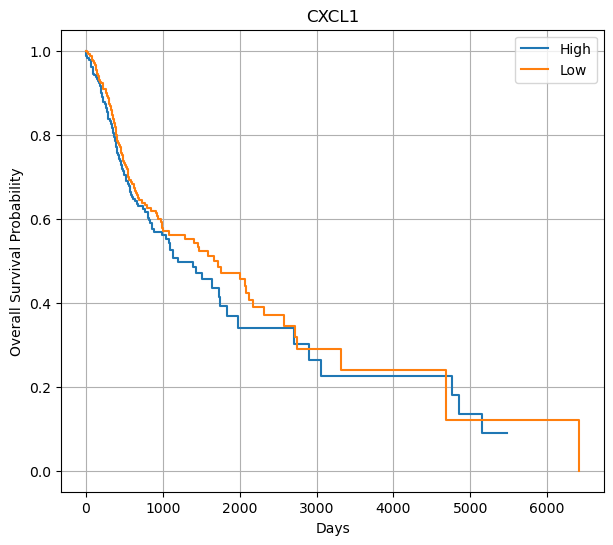

In [109]:
from lifelines import KaplanMeierFitter
import matplotlib.pyplot as plt

plt.figure(figsize=(7,6))

kmf = KaplanMeierFitter()

for group in ["High", "Low"]:

    subset = df[df["Group"] == group]

    kmf.fit(
        durations=subset["OS_days"],
        event_observed=subset["Event"],
        label=group
    )

    kmf.plot_survival_function(ci_show=False)

plt.xlabel("Days")
plt.ylabel("Overall Survival Probability")
plt.title(gene)
plt.legend()
plt.grid(True)

plt.show()

In [110]:
from lifelines.statistics import logrank_test

high = df[df["Group"]=="High"]
low = df[df["Group"]=="Low"]

result = logrank_test(
    high["OS_days"],
    low["OS_days"],
    event_observed_A=high["Event"],
    event_observed_B=low["Event"]
)

print(result.summary)

   test_statistic        p  -log2(p)
0        0.957412  0.32784  1.608937


In [111]:
import pandas as pd
import numpy as np

expr = pd.read_csv("HNSC_expression_521_patients.csv")
survival = pd.read_csv("HNSC_survival_521_patients.csv")

print(expr.shape)
print(survival.shape)

(60660, 523)
(521, 3)


In [112]:
annotation = pd.read_csv("AP1_annotation.txt", sep="\t")

print(annotation.shape)
annotation.head()

(116, 19)


,PeakID (cmd=annotatePeaks.pl SetA_AP1primed_hg38.bed hg38),Chr,Start,End,Strand,Peak Score,Focus Ratio/Region Size,Annotation,Detailed Annotation,Distance to TSS,Nearest PromoterID,Entrez ID,Nearest Unigene,Nearest Refseq,Nearest Ensembl,Gene Name,Gene Alias,Gene Description,Gene Type
0,1.6402,chr15,59232420,59232718,+,0,NaN,"intron (NM_004998, intron 5 of 27)","intron (NM_004998, intron 5 of 27)",25726,NM_033195,92483,NaN,NM_033195,ENSG00000171989,LDHAL6B,LDH6B|LDHAL6|LDHL,lactate dehydrogenase A like 6B,protein-coding
1,1.1153,chr1,84856710,84857038,+,0,NaN,"intron (NM_012152, intron 2 of 2)","intron (NM_012152, intron 2 of 2)",36332,NM_012152,23566,NaN,NM_012152,ENSG00000171517,LPAR3,EDG7|Edg-7|GPCR|HOFNH30|LP-A3|LPA3|RP4-678I3,lysophosphatidic acid receptor 3,protein-coding
2,1.6001,chr16,56848032,56849433,+,0,NaN,"3' UTR (NM_001242795, exon 20 of 20)","3' UTR (NM_001242795, exon 20 of 20)",-9786,NR_029680,406930,NaN,NR_029680,ENSG00000207649,MIR138-2,MIRN138-2|mir-138-2,microRNA 138-2,ncRNA
3,1.3308,chr1,58727384,58727802,+,0,NaN,Intergenic,Intergenic,-27531,NM_001085487,114803,NaN,NM_001085487,ENSG00000162601,MYSM1,2A-DUB|2ADUB|BMFS4,"Myb like, SWIRM and MPN domains 1",protein-coding
4,2.4675,chr15,63355698,63357443,+,0,NaN,"intron (NM_206925, intron 2 of 9)",AluSz|SINE|Alu,25276,NR_135511,771,NaN,NM_001218,ENSG00000074410,CA12,CA-XII|CAXII|HsT18816|T18816,carbonic anhydrase 12,protein-coding


In [113]:
genes = (
    annotation["Gene Name"]
    .dropna()
    .astype(str)
    .str.strip()
)

genes = genes[(genes != "") & (genes != "-")]

genes = sorted(genes.unique())

print("Unique annotated genes:", len(genes))

Unique annotated genes: 114


In [114]:
tcga_genes = set(expr["gene_name"])

genes = [g for g in genes if g in tcga_genes]

print("Genes found in TCGA:", len(genes))
print(genes[:20])

Genes found in TCGA: 106
['ABHD2', 'ACO1', 'ACTN1', 'ADRB2', 'ALOX12P2', 'ANK2', 'ANO10', 'ASB7', 'ATG10', 'ATP8B1', 'ATXN10', 'BEST3', 'BRD2', 'C19orf25', 'CA12', 'CALD1', 'CAP1', 'CEMIP2', 'CXCL1', 'CYP1B1-AS1']


In [115]:
from lifelines import CoxPHFitter
from lifelines.statistics import logrank_test
from statsmodels.stats.multitest import multipletests
import pandas as pd
import numpy as np

In [116]:
results = []

for gene in genes:

    # Get expression row
    row = expr[expr["gene_name"] == gene]

    if row.empty:
        continue

    expression = row.iloc[0, 2:].astype(float)
    expression.index = expr.columns[2:]

    # Build dataframe
    df = survival.copy()

    df["Expression"] = expression.loc[
        df["cases.submitter_id"]
    ].values

    df = df.dropna(subset=["OS_days"])

    # ----------------------------
    # Cox regression
    # ----------------------------

    cox_df = df[["OS_days", "Event", "Expression"]].copy()

    try:

        cph = CoxPHFitter()

        cph.fit(
            cox_df,
            duration_col="OS_days",
            event_col="Event"
        )

        hr = np.exp(cph.params_["Expression"])

        p = cph.summary.loc["Expression", "p"]

        ci_low = cph.summary.loc[
            "Expression",
            "exp(coef) lower 95%"
        ]

        ci_high = cph.summary.loc[
            "Expression",
            "exp(coef) upper 95%"
        ]

    except:

        hr = np.nan
        p = np.nan
        ci_low = np.nan
        ci_high = np.nan

    # ----------------------------
    # Kaplan-Meier p-value
    # ----------------------------

    median = df["Expression"].median()

    df["Group"] = np.where(
        df["Expression"] >= median,
        "High",
        "Low"
    )

    high = df[df["Group"] == "High"]

    low = df[df["Group"] == "Low"]

    try:

        km = logrank_test(
            high["OS_days"],
            low["OS_days"],
            event_observed_A=high["Event"],
            event_observed_B=low["Event"]
        )

        km_p = km.p_value

    except:

        km_p = np.nan

    results.append([
        gene,
        hr,
        ci_low,
        ci_high,
        p,
        km_p
    ])

/Users/sampoorn/Desktop/SC_projects/single_cell_projects/environments/envs/scverse-2026/lib/python3.11/site-packages/lifelines/utils/__init__.py:1100: ConvergenceWarning: Column(s) ['Expression'] have very low variance. This may harm convergence. 1) Are you using formula's? Did you mean to add '-1' to the end. 2) Try dropping this redundant column before fitting if convergence fails.

  warnings.warn(dedent(warning_text), ConvergenceWarning)
/Users/sampoorn/Desktop/SC_projects/single_cell_projects/environments/envs/scverse-2026/lib/python3.11/site-packages/lifelines/utils/__init__.py:1100: ConvergenceWarning: Column(s) ['Expression'] have very low variance. This may harm convergence. 1) Are you using formula's? Did you mean to add '-1' to the end. 2) Try dropping this redundant column before fitting if convergence fails.

  warnings.warn(dedent(warning_text), ConvergenceWarning)


In [117]:
results = []

for gene in genes:

    # Get expression row
    row = expr[expr["gene_name"] == gene]

    if row.empty:
        continue

    expression = row.iloc[0, 2:].astype(float)
    expression.index = expr.columns[2:]

    # Build dataframe
    df = survival.copy()

    df["Expression"] = expression.loc[
        df["cases.submitter_id"]
    ].values

    df = df.dropna(subset=["OS_days"])

    # ----------------------------
    # Cox regression
    # ----------------------------

    cox_df = df[["OS_days", "Event", "Expression"]].copy()

    try:

        cph = CoxPHFitter()

        cph.fit(
            cox_df,
            duration_col="OS_days",
            event_col="Event"
        )

        hr = np.exp(cph.params_["Expression"])

        p = cph.summary.loc["Expression", "p"]

        ci_low = cph.summary.loc[
            "Expression",
            "exp(coef) lower 95%"
        ]

        ci_high = cph.summary.loc[
            "Expression",
            "exp(coef) upper 95%"
        ]

    except:

        hr = np.nan
        p = np.nan
        ci_low = np.nan
        ci_high = np.nan

    # ----------------------------
    # Kaplan-Meier p-value
    # ----------------------------

    median = df["Expression"].median()

    df["Group"] = np.where(
        df["Expression"] >= median,
        "High",
        "Low"
    )

    high = df[df["Group"] == "High"]

    low = df[df["Group"] == "Low"]

    try:

        km = logrank_test(
            high["OS_days"],
            low["OS_days"],
            event_observed_A=high["Event"],
            event_observed_B=low["Event"]
        )

        km_p = km.p_value

    except:

        km_p = np.nan

    results.append([
        gene,
        hr,
        ci_low,
        ci_high,
        p,
        km_p
    ])

/Users/sampoorn/Desktop/SC_projects/single_cell_projects/environments/envs/scverse-2026/lib/python3.11/site-packages/lifelines/utils/__init__.py:1100: ConvergenceWarning: Column(s) ['Expression'] have very low variance. This may harm convergence. 1) Are you using formula's? Did you mean to add '-1' to the end. 2) Try dropping this redundant column before fitting if convergence fails.

  warnings.warn(dedent(warning_text), ConvergenceWarning)
/Users/sampoorn/Desktop/SC_projects/single_cell_projects/environments/envs/scverse-2026/lib/python3.11/site-packages/lifelines/utils/__init__.py:1100: ConvergenceWarning: Column(s) ['Expression'] have very low variance. This may harm convergence. 1) Are you using formula's? Did you mean to add '-1' to the end. 2) Try dropping this redundant column before fitting if convergence fails.

  warnings.warn(dedent(warning_text), ConvergenceWarning)


In [118]:
results = pd.DataFrame(
    results,
    columns=[
        "Gene",
        "HazardRatio",
        "CI_lower",
        "CI_upper",
        "Cox_p",
        "KM_p"
    ]
)

results.head()

,Gene,HazardRatio,CI_lower,CI_upper,Cox_p,KM_p
0,ABHD2,1.000013,0.999994,1.000031,0.174440,0.568025
1,ACO1,1.000093,0.999990,1.000195,0.077556,0.076815
2,ACTN1,1.000006,1.000000,1.000012,0.035476,0.008638
3,ADRB2,0.999989,0.999866,1.000113,0.863517,0.465620
4,ALOX12P2,1.000258,0.999796,1.000719,0.274316,0.476403


In [119]:
results["FDR"] = multipletests(
    results["Cox_p"],
    method="fdr_bh"
)[1]

results = results.sort_values("Cox_p")

results.head(20)

,Gene,HazardRatio,CI_lower,CI_upper,Cox_p,KM_p,FDR
68,MSANTD3,1.000281,1.000118,1.000445,0.000756,0.010466,NaN
33,GADD45B,1.000099,1.000037,1.000160,0.001702,0.006824,NaN
102,ZBED5-AS1,1.000862,1.000273,1.001451,0.004112,0.524782,NaN
26,FAM53B,0.999892,0.999815,0.999969,0.005731,0.086014,NaN
18,CXCL1,1.000020,1.000005,1.000034,0.006932,0.327840,NaN
80,PIP5K1A,1.000099,1.000026,1.000172,0.008071,0.068835,NaN
43,L1CAM,1.000032,1.000007,1.000057,0.010699,0.019123,NaN
99,UBE2L3,1.000072,1.000014,1.000129,0.014171,0.063215,NaN
69,MYOF,1.000018,1.000003,1.000032,0.014903,0.084864,NaN
84,PRR7,1.000870,1.000165,1.001575,0.015554,0.106353,NaN


In [120]:
results.to_csv(
    "AP1_TCGA_HNSC_survival_results.csv",
    index=False
)

print(results.shape)

(106, 7)


In [121]:
sig = results[
    results["FDR"] < 0.05
]

print(sig)

Empty DataFrame
Columns: [Gene, HazardRatio, CI_lower, CI_upper, Cox_p, KM_p, FDR]
Index: []


In [122]:
results["Cox_p"].isna().sum()

np.int64(2)

In [123]:
from statsmodels.stats.multitest import multipletests

results["FDR"] = np.nan

mask = results["Cox_p"].notna()

results.loc[mask, "FDR"] = multipletests(
    results.loc[mask, "Cox_p"],
    method="fdr_bh"
)[1]

results = results.sort_values("Cox_p")

results.head(20)

,Gene,HazardRatio,CI_lower,CI_upper,Cox_p,KM_p,FDR
68,MSANTD3,1.000281,1.000118,1.000445,0.000756,0.010466,0.078633
33,GADD45B,1.000099,1.000037,1.000160,0.001702,0.006824,0.088498
102,ZBED5-AS1,1.000862,1.000273,1.001451,0.004112,0.524782,0.139890
26,FAM53B,0.999892,0.999815,0.999969,0.005731,0.086014,0.139890
18,CXCL1,1.000020,1.000005,1.000034,0.006932,0.327840,0.139890
80,PIP5K1A,1.000099,1.000026,1.000172,0.008071,0.068835,0.139890
43,L1CAM,1.000032,1.000007,1.000057,0.010699,0.019123,0.157259
99,UBE2L3,1.000072,1.000014,1.000129,0.014171,0.063215,0.157259
69,MYOF,1.000018,1.000003,1.000032,0.014903,0.084864,0.157259
84,PRR7,1.000870,1.000165,1.001575,0.015554,0.106353,0.157259


In [124]:
expression = np.log2(expression + 1)

In [125]:
import pandas as pd
import numpy as np

expr = pd.read_csv("normalized_logCPM.csv")

print(expr.shape)
expr.head()

FileNotFoundError: [Errno 2] No such file or directory: 'normalized_logCPM.csv'

In [127]:
# expr has genes in rows and patients in columns

module = expr[
    expr["gene_name"].isin(genes)
]

module.shape

(106, 523)

In [129]:
module = expr[expr["gene_name"].isin(genes)].copy()

print(module.shape)

(106, 523)


In [130]:
expr_matrix = module.iloc[:, 2:].astype(float)

# Z-score each gene across patients
expr_z = expr_matrix.sub(expr_matrix.mean(axis=1), axis=0)
expr_z = expr_z.div(expr_matrix.std(axis=1), axis=0)

print(expr_z.shape)

(106, 521)


In [131]:
module_score = expr_z.mean(axis=0)

module_score.name = "ModuleScore"

module_score.describe()

count    5.210000e+02
mean     1.022854e-17
std      3.410114e-01
min     -7.628317e-01
25%     -2.420371e-01
50%     -4.167468e-02
75%      2.258320e-01
max      1.374466e+00
Name: ModuleScore, dtype: float64

In [132]:
df = survival.copy()

df["ModuleScore"] = module_score.loc[
    df["cases.submitter_id"]
].values

df = df.dropna(subset=["OS_days"])

print(df.shape)
df.head()

(477, 4)


,cases.submitter_id,OS_days,Event,ModuleScore
0,TCGA-4P-AA8J,102.0,0,-0.410085
1,TCGA-BA-4074,462.0,1,0.450469
2,TCGA-BA-4075,283.0,1,-0.164259
3,TCGA-BA-4076,415.0,1,-0.208827
4,TCGA-BA-4077,1134.0,1,-0.193885


In [133]:
from lifelines import CoxPHFitter

cox = CoxPHFitter()

cox.fit(
    df[["OS_days", "Event", "ModuleScore"]],
    duration_col="OS_days",
    event_col="Event"
)

cox.summary

,coef,exp(coef),se(coef),coef lower 95%,coef upper 95%,exp(coef) lower 95%,exp(coef) upper 95%,cmp to,z,p,-log2(p)
covariate,,,,,,,,,,,
ModuleScore,0.267231,1.306342,0.199679,-0.124132,0.658594,0.883263,1.932074,0.0,1.338304,0.180797,2.467554


In [134]:
median = df["ModuleScore"].median()

df["Group"] = np.where(
    df["ModuleScore"] >= median,
    "High AP1",
    "Low AP1"
)

In [136]:
median = df["ModuleScore"].median()

df["Group"] = np.where(
    df["ModuleScore"] >= median,
    "High",
    "Low"
)

print(df["Group"].value_counts())

Group
High    239
Low     238
Name: count, dtype: int64


In [137]:
print(df.dtypes)

print(df[["OS_days","Event","ModuleScore"]].head())

cases.submitter_id     object
OS_days               float64
Event                   int64
ModuleScore           float64
Group                  object
dtype: object
   OS_days  Event  ModuleScore
0    102.0      0    -0.410085
1    462.0      1     0.450469
2    283.0      1    -0.164259
3    415.0      1    -0.208827
4   1134.0      1    -0.193885


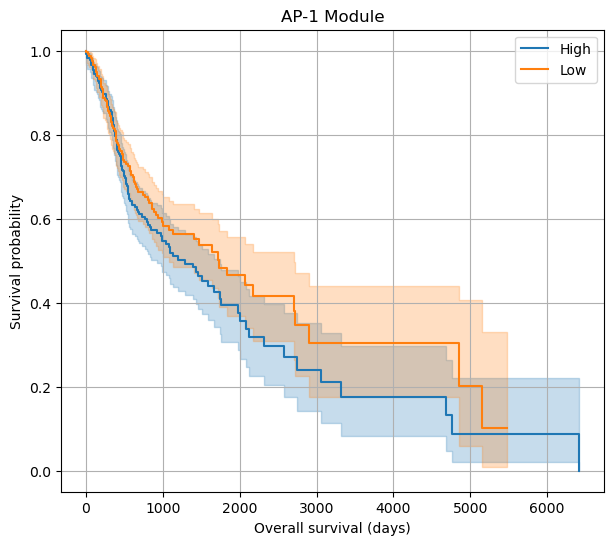

In [138]:
from lifelines import KaplanMeierFitter
import matplotlib.pyplot as plt

kmf = KaplanMeierFitter()

plt.figure(figsize=(7,6))

for grp in ["High", "Low"]:

    sub = df[df["Group"] == grp]

    kmf.fit(
        durations=sub["OS_days"],
        event_observed=sub["Event"],
        label=grp
    )

    kmf.plot_survival_function(ci_show=True)

plt.title("AP-1 Module")
plt.xlabel("Overall survival (days)")
plt.ylabel("Survival probability")
plt.grid(True)
plt.show()

,Gene,HR,Lower95,Upper95,P,FDR
66,MSANTD3,1.000281,1.000118,1.000445,0.000756,0.078633
33,GADD45B,1.000099,1.000037,1.000160,0.001702,0.088498
100,ZBED5-AS1,1.000862,1.000273,1.001451,0.004112,0.139890
26,FAM53B,0.999892,0.999815,0.999969,0.005731,0.139890
18,CXCL1,1.000020,1.000005,1.000034,0.006932,0.139890
78,PIP5K1A,1.000099,1.000026,1.000172,0.008071,0.139890
43,L1CAM,1.000032,1.000007,1.000057,0.010699,0.157259
97,UBE2L3,1.000072,1.000014,1.000129,0.014171,0.157259
67,MYOF,1.000018,1.000003,1.000032,0.014903,0.157259
82,PRR7,1.000870,1.000165,1.001575,0.015554,0.157259


In [142]:
results[
    results["FDR"] < 0.05
]

,Gene,HR,Lower95,Upper95,P,FDR


In [145]:
import numpy as np
import pandas as pd

from lifelines import CoxPHFitter
from statsmodels.stats.multitest import multipletests

###############################################################
# expr      : Expression matrix
# survival  : Survival dataframe
# genes     : List of 106 AP-1 genes
###############################################################

results = []

patient_cols = expr.columns[2:]

for gene in genes:

    row = expr[expr["gene_name"] == gene]

    if row.empty:
        continue

    ###########################################################
    # Expression
    ###########################################################

    expression = row.iloc[0, 2:].astype(float)

    # IMPORTANT
    # If expr contains RAW COUNTS this converts to log2(count+1)
    # If expr already contains logCPM you can comment this line.
    expression = np.log2(expression + 1)

    expression.index = patient_cols

    ###########################################################
    # Merge with survival
    ###########################################################

    df = survival.copy()

    df["Expression"] = expression.loc[
        df["cases.submitter_id"]
    ].values

    df = df.dropna(
        subset=[
            "OS_days",
            "Event",
            "Expression"
        ]
    )

    ###########################################################
    # Skip genes with no variation
    ###########################################################

    if df["Expression"].std() == 0:
        continue

    ###########################################################
    # Z-score expression
    ###########################################################

    df["Expression"] = (
        df["Expression"] -
        df["Expression"].mean()
    ) / df["Expression"].std()

    ###########################################################
    # Cox model
    ###########################################################

    try:

        cph = CoxPHFitter()

        cph.fit(
            df[
                [
                    "OS_days",
                    "Event",
                    "Expression"
                ]
            ],
            duration_col="OS_days",
            event_col="Event"
        )

        s = cph.summary.loc["Expression"]

        results.append({

            "Gene":gene,

            "HR":s["exp(coef)"],

            "Lower95":s["exp(coef) lower 95%"],

            "Upper95":s["exp(coef) upper 95%"],

            "P":s["p"]

        })

    except Exception as e:

        print(f"{gene} failed")

###############################################################
# Results table
###############################################################

results = pd.DataFrame(results)

###############################################################
# FDR correction
###############################################################

mask = results["P"].notna()

results["FDR"] = np.nan

results.loc[mask,"FDR"] = multipletests(
    results.loc[mask,"P"],
    method="fdr_bh"
)[1]

###############################################################
# Sort
###############################################################

results = results.sort_values("P")

###############################################################
# Save
###############################################################

results.to_csv(
    "AP1_gene_survival_results.csv",
    index=False
)

###############################################################
# Display
###############################################################

print("="*70)
print("Top genes")
print("="*70)

display(results.head(25))

print("\n")

print("="*70)
print("Nominally significant genes (P < 0.05)")
print("="*70)

display(results[results["P"] < 0.05])

print("\n")

print("="*70)
print("FDR significant genes (FDR < 0.05)")
print("="*70)

display(results[results["FDR"] < 0.05])

print("\nSaved as AP1_gene_survival_results.csv")

Top genes


,Gene,HR,Lower95,Upper95,P,FDR
66,MSANTD3,1.226999,1.068201,1.409403,0.003816,0.183283
26,FAM53B,0.824155,0.721214,0.941789,0.004498,0.183283
82,PRR7,1.209583,1.058190,1.382636,0.005287,0.183283
14,CA12,1.216550,1.045354,1.415783,0.011303,0.199594
33,GADD45B,1.190088,1.040123,1.361676,0.011328,0.199594
97,UBE2L3,1.184153,1.035578,1.354044,0.013472,0.199594
2,ACTN1,1.187496,1.032150,1.366223,0.016291,0.199594
67,MYOF,1.205580,1.033770,1.405944,0.017156,0.199594
100,ZBED5-AS1,1.182486,1.030075,1.357447,0.017273,0.199594
11,BEST3,1.163098,1.024716,1.320168,0.019401,0.201770




Nominally significant genes (P < 0.05)


,Gene,HR,Lower95,Upper95,P,FDR
66,MSANTD3,1.226999,1.068201,1.409403,0.003816,0.183283
26,FAM53B,0.824155,0.721214,0.941789,0.004498,0.183283
82,PRR7,1.209583,1.058190,1.382636,0.005287,0.183283
14,CA12,1.216550,1.045354,1.415783,0.011303,0.199594
33,GADD45B,1.190088,1.040123,1.361676,0.011328,0.199594
97,UBE2L3,1.184153,1.035578,1.354044,0.013472,0.199594
2,ACTN1,1.187496,1.032150,1.366223,0.016291,0.199594
67,MYOF,1.205580,1.033770,1.405944,0.017156,0.199594
100,ZBED5-AS1,1.182486,1.030075,1.357447,0.017273,0.199594
11,BEST3,1.163098,1.024716,1.320168,0.019401,0.201770




FDR significant genes (FDR < 0.05)


,Gene,HR,Lower95,Upper95,P,FDR



Saved as AP1_gene_survival_results.csv


In [146]:
genes = [
    "PRR7",
    "LMO7",
    "LINC02410",
    "MSANTD3",
    "NECTIN1",
    "UTRN",
    "MIR6078",
    "ZNF462",
    "ASB7",
    "HOPX",
    "NRP1",
    "CXCL1",
    "EXT1",
    "ATG10"
]

In [147]:
module = expr[expr["gene_name"].isin(genes)].copy()

print("Genes found:", module.shape[0])
print(module["gene_name"].tolist())

Genes found: 14
['MSANTD3', 'NRP1', 'NECTIN1', 'PRR7', 'LMO7', 'ZNF462', 'ATG10', 'UTRN', 'CXCL1', 'HOPX', 'EXT1', 'ASB7', 'LINC02410', 'MIR6078']


In [148]:
expr_matrix = module.iloc[:, 2:].astype(float)

expr_z = expr_matrix.sub(expr_matrix.mean(axis=1), axis=0)
expr_z = expr_z.div(expr_matrix.std(axis=1), axis=0)

In [149]:
module_score = expr_z.mean(axis=0)

module_score.name = "ModuleScore"

print(module_score.describe())

count    5.210000e+02
mean     3.409514e-18
std      4.015417e-01
min     -9.199811e-01
25%     -2.952235e-01
50%     -3.670123e-02
75%      2.401523e-01
max      2.048744e+00
Name: ModuleScore, dtype: float64


In [150]:
df = survival.copy()

df["ModuleScore"] = module_score.loc[df["cases.submitter_id"]].values

df = df.dropna(subset=["OS_days"])

print(df.shape)

(477, 4)


In [151]:
from lifelines import CoxPHFitter

cox = CoxPHFitter()

cox.fit(
    df[["OS_days", "Event", "ModuleScore"]],
    duration_col="OS_days",
    event_col="Event"
)

cox.print_summary()

<lifelines.CoxPHFitter: fitted with 477 total observations, 257 right-censored observations>
             duration col = 'OS_days'
                event col = 'Event'
      baseline estimation = breslow
   number of observations = 477
number of events observed = 220
   partial log-likelihood = -1183.32
         time fit was run = 2026-06-24 08:04:11 UTC

---
             coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                    
ModuleScore  0.41      1.50      0.17            0.08            0.73                1.09                2.08

             cmp to    z    p  -log2(p)
covariate                              
ModuleScore    0.00 2.46 0.01      6.19
---
Concordance = 0.54
Partial AIC = 2368.64
log-likelihood ratio test = 5.85 on 1 df
-log2(p) of ll-ratio test = 6.01

In [152]:
import numpy as np

median = df["ModuleScore"].median()

df["Group"] = np.where(
    df["ModuleScore"] >= median,
    "High Module",
    "Low Module"
)

print(df["Group"].value_counts())

Group
High Module    239
Low Module     238
Name: count, dtype: int64


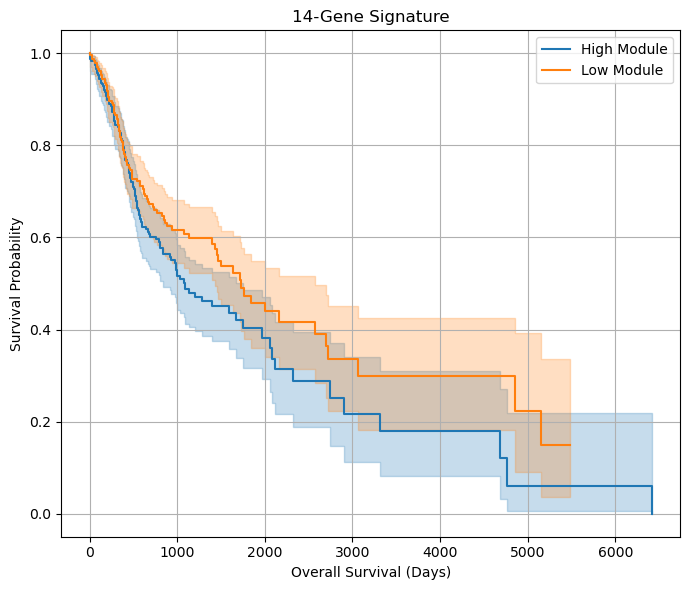

In [153]:
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test
import matplotlib.pyplot as plt

kmf = KaplanMeierFitter()

plt.figure(figsize=(7,6))

for group in ["High Module", "Low Module"]:

    subset = df[df["Group"] == group]

    kmf.fit(
        durations=subset["OS_days"],
        event_observed=subset["Event"],
        label=group
    )

    kmf.plot_survival_function(ci_show=True)

plt.xlabel("Overall Survival (Days)")
plt.ylabel("Survival Probability")
plt.title("14-Gene Signature")
plt.grid(True)
plt.tight_layout()
plt.show()

In [154]:
high = df[df["Group"] == "High Module"]
low = df[df["Group"] == "Low Module"]

result = logrank_test(
    high["OS_days"],
    low["OS_days"],
    event_observed_A=high["Event"],
    event_observed_B=low["Event"]
)

print(result.summary)

   test_statistic         p  -log2(p)
0        3.590423  0.058113  4.104984


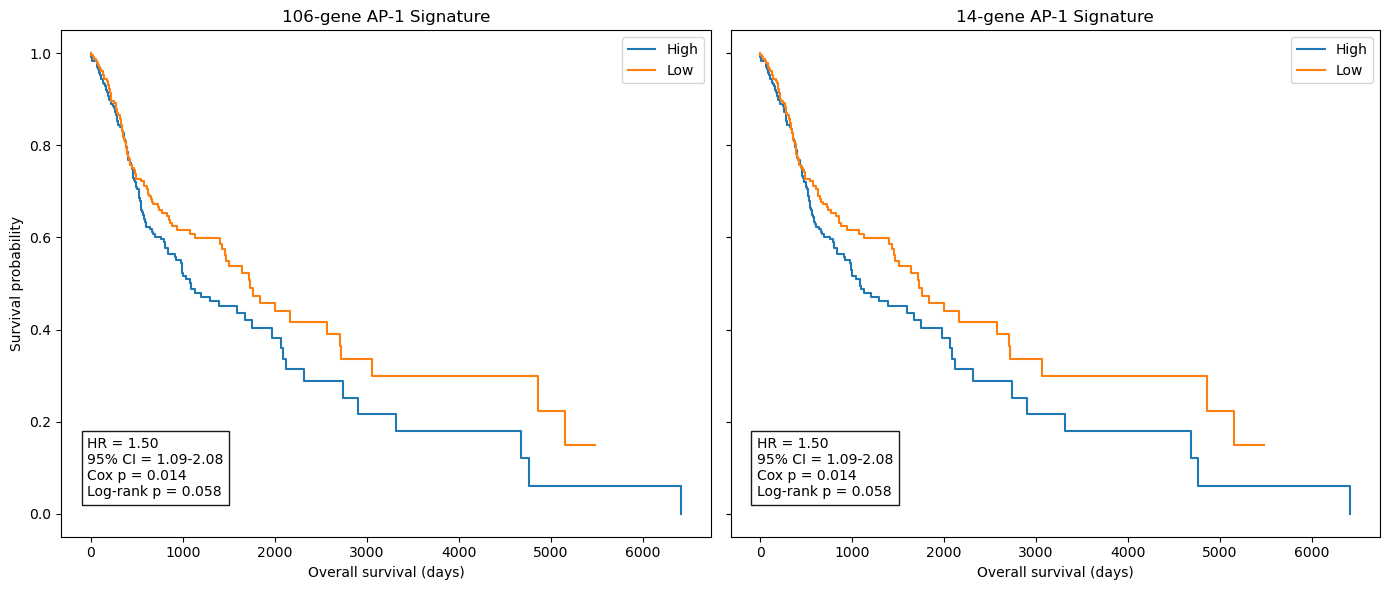

,Signature,HR,Lower95,Upper95,Cox_P,LogRank_P
0,106-gene,1.502322,1.086931,2.076462,0.013711,0.058113
1,14-gene,1.502322,1.086931,2.076462,0.013711,0.058113


In [158]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import logrank_test

###############################################################
# Put your two gene lists here
###############################################################

# genes_106 = [...]
# genes_14 = [...]

###############################################################
# Function
###############################################################

def module_survival(expr, survival, gene_list):

    module = expr[expr["gene_name"].isin(gene_list)].copy()

    expr_matrix = module.iloc[:,2:].astype(float)

    # Uncomment ONLY if expr contains raw counts
    # expr_matrix = np.log2(expr_matrix + 1)

    # Z-score each gene
    expr_z = expr_matrix.sub(expr_matrix.mean(axis=1), axis=0)
    expr_z = expr_z.div(expr_matrix.std(axis=1), axis=0)

    module_score = expr_z.mean(axis=0)

    df = survival.copy()

    df["ModuleScore"] = module_score.loc[
        df["cases.submitter_id"]
    ].values

    df = df.dropna(subset=["OS_days"])

    median = df["ModuleScore"].median()

    df["Group"] = np.where(
        df["ModuleScore"] >= median,
        "High",
        "Low"
    )

    ###########################################################

    cph = CoxPHFitter()

    cph.fit(
        df[
            [
                "OS_days",
                "Event",
                "ModuleScore"
            ]
        ],
        duration_col="OS_days",
        event_col="Event"
    )

    summary = cph.summary.loc["ModuleScore"]

    HR = summary["exp(coef)"]
    lower = summary["exp(coef) lower 95%"]
    upper = summary["exp(coef) upper 95%"]
    cox_p = summary["p"]

    ###########################################################

    high = df[df["Group"]=="High"]
    low = df[df["Group"]=="Low"]

    lr = logrank_test(
        high["OS_days"],
        low["OS_days"],
        event_observed_A=high["Event"],
        event_observed_B=low["Event"]
    )

    return df, HR, lower, upper, cox_p, lr.p_value


###############################################################
# Run analyses
###############################################################

df106, hr106, l106, u106, cox106, km106 = module_survival(
    expr,
    survival,
    genes_106
)

df14, hr14, l14, u14, cox14, km14 = module_survival(
    expr,
    survival,
    genes_14
)

###############################################################
# Plot
###############################################################

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14,6),
    sharey=True
)

kmf = KaplanMeierFitter()

###############################################################
# 106 genes
###############################################################

for grp in ["High","Low"]:

    sub = df106[df106["Group"]==grp]

    kmf.fit(
        sub["OS_days"],
        sub["Event"],
        label=grp
    )

    kmf.plot_survival_function(
        ax=axes[0],
        ci_show=False
    )

axes[0].set_title("106-gene AP-1 Signature")

axes[0].text(
    0.04,
    0.08,
    f"HR = {hr106:.2f}\n"
    f"95% CI = {l106:.2f}-{u106:.2f}\n"
    f"Cox p = {cox106:.3f}\n"
    f"Log-rank p = {km106:.3f}",
    transform=axes[0].transAxes,
    fontsize=10,
    bbox=dict(facecolor="white",alpha=0.9)
)

axes[0].set_xlabel("Overall survival (days)")
axes[0].set_ylabel("Survival probability")

###############################################################
# 14 genes
###############################################################

for grp in ["High","Low"]:

    sub = df14[df14["Group"]==grp]

    kmf.fit(
        sub["OS_days"],
        sub["Event"],
        label=grp
    )

    kmf.plot_survival_function(
        ax=axes[1],
        ci_show=False
    )

axes[1].set_title("14-gene AP-1 Signature")

axes[1].text(
    0.04,
    0.08,
    f"HR = {hr14:.2f}\n"
    f"95% CI = {l14:.2f}-{u14:.2f}\n"
    f"Cox p = {cox14:.3f}\n"
    f"Log-rank p = {km14:.3f}",
    transform=axes[1].transAxes,
    fontsize=10,
    bbox=dict(facecolor="white",alpha=0.9)
)

axes[1].set_xlabel("Overall survival (days)")

plt.tight_layout()

plt.savefig(
    "AP1_signature_comparison.png",
    dpi=600,
    bbox_inches="tight"
)

plt.savefig(
    "AP1_signature_comparison.pdf",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

###############################################################
# Summary
###############################################################

summary = pd.DataFrame({

    "Signature":[
        "106-gene",
        "14-gene"
    ],

    "HR":[
        hr106,
        hr14
    ],

    "Lower95":[
        l106,
        l14
    ],

    "Upper95":[
        u106,
        u14
    ],

    "Cox_P":[
        cox106,
        cox14
    ],

    "LogRank_P":[
        km106,
        km14
    ]

})

display(summary)

In [159]:
[x for x in globals().keys() if "gene" in x.lower()]

['zero_genes',
 'gene_info',
 'gene',
 'gene_row',
 'genes',
 'tcga_genes',
 'df_gene',
 'genes_106',
 'genes_14']

In [160]:
print(len(genes_106))

14


In [157]:
# 106-gene signature
genes_106 = genes

# 14-gene signature
genes_14 = [
    'PRR7',
    'LMO7',
    'LINC02410',
    'MSANTD3',
    'NECTIN1',
    'UTRN',
    'MIR6078',
    'ZNF462',
    'ASB7',
    'HOPX',
    'NRP1',
    'CXCL1',
    'EXT1',
    'ATG10'
]

In [161]:
print(annotation.columns)

Index(['PeakID (cmd=annotatePeaks.pl SetA_AP1primed_hg38.bed hg38)', 'Chr',
       'Start', 'End', 'Strand', 'Peak Score', 'Focus Ratio/Region Size',
       'Annotation', 'Detailed Annotation', 'Distance to TSS',
       'Nearest PromoterID', 'Entrez ID', 'Nearest Unigene', 'Nearest Refseq',
       'Nearest Ensembl', 'Gene Name', 'Gene Alias', 'Gene Description',
       'Gene Type'],
      dtype='object')


In [162]:
genes_106 = (
    annotation["Gene Name"]
    .dropna()
    .astype(str)
    .str.strip()
    .unique()
    .tolist()
)

print("Number of genes:", len(genes_106))
print(genes_106[:10])

Number of genes: 114
['LDHAL6B', 'LPAR3', 'MIR138-2', 'MYSM1', 'CA12', 'GNAQ', 'LINC02012', 'LINC02026', 'EIF1B', 'SEM1']


In [163]:
tcga_genes = set(expr["gene_name"])

genes_106 = [
    g for g in annotation["Gene Name"]
    .dropna()
    .astype(str)
    .str.strip()
    .unique()
    if g in tcga_genes
]

print("Genes in annotation :", annotation["Gene Name"].nunique())
print("Genes in TCGA :", len(genes_106))

Genes in annotation : 114
Genes in TCGA : 106


In [164]:
genes_114 = (
    annotation["Gene Name"]
    .dropna()
    .astype(str)
    .str.strip()
    .unique()
    .tolist()
)

genes_106 = [
    g for g in genes_114
    if g in tcga_genes
]

genes_14 = [
    'PRR7','LMO7','LINC02410','MSANTD3','NECTIN1',
    'UTRN','MIR6078','ZNF462','ASB7','HOPX',
    'NRP1','CXCL1','EXT1','ATG10'
]

In [165]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import logrank_test


def analyze_signature(expr, survival, gene_list, title):

    ############################################################
    # Extract genes
    ############################################################

    module = expr[expr["gene_name"].isin(gene_list)].copy()

    found = module["gene_name"].nunique()

    ############################################################
    # Expression matrix
    ############################################################

    expr_matrix = module.iloc[:,2:].astype(float)

    # Uncomment ONLY if expr contains RAW COUNTS
    # expr_matrix = np.log2(expr_matrix + 1)

    ############################################################
    # Z-score each gene
    ############################################################

    expr_z = expr_matrix.sub(expr_matrix.mean(axis=1), axis=0)
    expr_z = expr_z.div(expr_matrix.std(axis=1), axis=0)

    ############################################################
    # Module score
    ############################################################

    module_score = expr_z.mean(axis=0)

    ############################################################
    # Survival dataframe
    ############################################################

    df = survival.copy()

    df["ModuleScore"] = module_score.loc[
        df["cases.submitter_id"]
    ].values

    df = df.dropna(subset=["OS_days"])

    ############################################################
    # High vs Low
    ############################################################

    median = df["ModuleScore"].median()

    df["Group"] = np.where(
        df["ModuleScore"] >= median,
        "High",
        "Low"
    )

    ############################################################
    # Cox model
    ############################################################

    cph = CoxPHFitter()

    cph.fit(
        df[
            [
                "OS_days",
                "Event",
                "ModuleScore"
            ]
        ],
        duration_col="OS_days",
        event_col="Event"
    )

    s = cph.summary.loc["ModuleScore"]

    ############################################################
    # Log-rank
    ############################################################

    high = df[df["Group"]=="High"]
    low = df[df["Group"]=="Low"]

    lr = logrank_test(
        high["OS_days"],
        low["OS_days"],
        event_observed_A=high["Event"],
        event_observed_B=low["Event"]
    )

    return {
        "title":title,
        "df":df,
        "found":found,
        "HR":s["exp(coef)"],
        "Lower":s["exp(coef) lower 95%"],
        "Upper":s["exp(coef) upper 95%"],
        "CoxP":s["p"],
        "LogRank":lr.p_value
    }

In [166]:
sig106 = analyze_signature(
    expr,
    survival,
    genes_106,
    "106-gene AP-1 Signature"
)

sig14 = analyze_signature(
    expr,
    survival,
    genes_14,
    "14-gene AP-1 Signature"
)

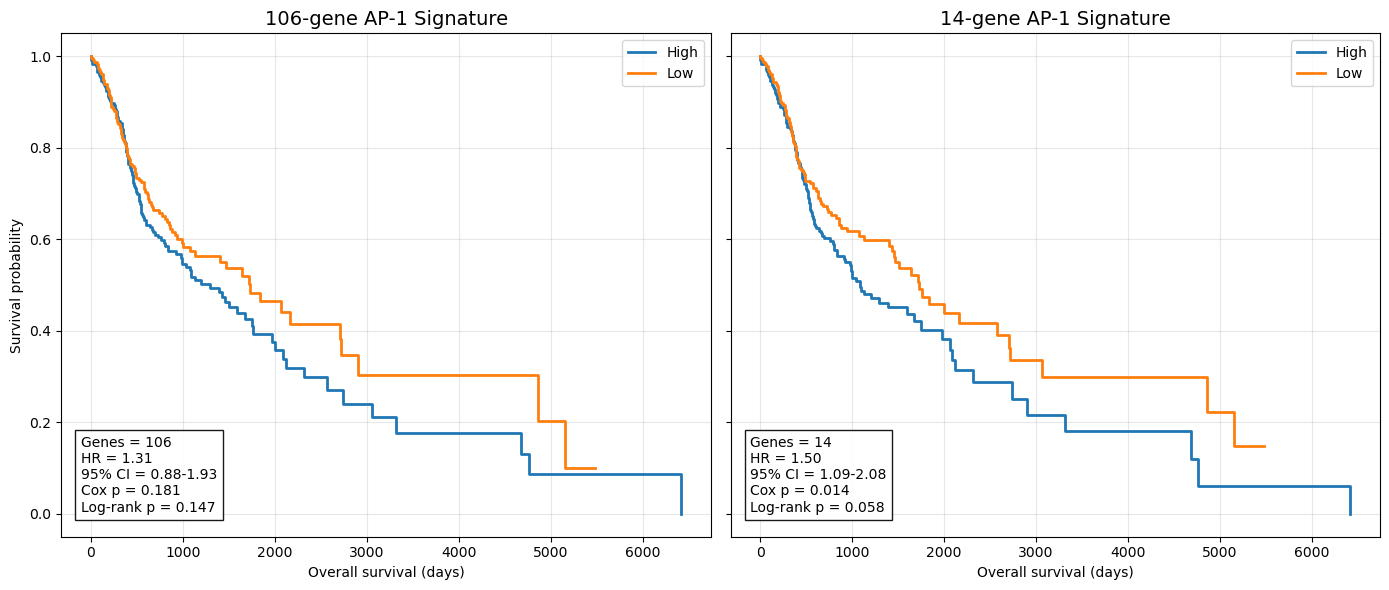

In [167]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(14,6),
    sharey=True
)

kmf = KaplanMeierFitter()

for ax, sig in zip(axes, [sig106, sig14]):

    for grp in ["High","Low"]:

        sub = sig["df"][sig["df"]["Group"]==grp]

        kmf.fit(
            sub["OS_days"],
            sub["Event"],
            label=grp
        )

        kmf.plot_survival_function(
            ax=ax,
            ci_show=False,
            linewidth=2
        )

    ax.set_title(sig["title"],fontsize=14)

    ax.set_xlabel("Overall survival (days)")
    ax.set_ylabel("Survival probability")

    ax.grid(alpha=0.3)

    text = (
        f"Genes = {sig['found']}\n"
        f"HR = {sig['HR']:.2f}\n"
        f"95% CI = {sig['Lower']:.2f}-{sig['Upper']:.2f}\n"
        f"Cox p = {sig['CoxP']:.3f}\n"
        f"Log-rank p = {sig['LogRank']:.3f}"
    )

    ax.text(
        0.03,
        0.05,
        text,
        transform=ax.transAxes,
        fontsize=10,
        bbox=dict(
            facecolor="white",
            edgecolor="black",
            alpha=0.9
        )
    )

plt.tight_layout()

plt.savefig(
    "AP1_signature_comparison.pdf",
    dpi=600,
    bbox_inches="tight"
)

plt.savefig(
    "AP1_signature_comparison.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()


In [168]:
summary = pd.DataFrame({

    "Signature":[
        sig106["title"],
        sig14["title"]
    ],

    "Genes":[
        sig106["found"],
        sig14["found"]
    ],

    "Hazard Ratio":[
        sig106["HR"],
        sig14["HR"]
    ],

    "95% CI":[
        f"{sig106['Lower']:.2f}-{sig106['Upper']:.2f}",
        f"{sig14['Lower']:.2f}-{sig14['Upper']:.2f}"
    ],

    "Cox p":[
        sig106["CoxP"],
        sig14["CoxP"]
    ],

    "Log-rank p":[
        sig106["LogRank"],
        sig14["LogRank"]
    ]

})

summary

,Signature,Genes,Hazard Ratio,95% CI,Cox p,Log-rank p
0,106-gene AP-1 Signature,106,1.306342,0.88-1.93,0.180797,0.146767
1,14-gene AP-1 Signature,14,1.502322,1.09-2.08,0.013711,0.058113
